# Gemma 4 H/k v2_planact Sweep Notebook

Dieses Notebook startet den H/k-Agent-Runner fuer den 12-Task-Sweep mit `gemma4:26b` als Planner und `gemma4:e4b` als Executor. Standardmaessig laeuft es ueber den lokalen Ollama-kompatiblen Proxy zur Google Vertex AI MaaS API.

Methodischer Hinweis fuer die Masterarbeit: `v2_planact` ist eine Architekturvariante zur besseren Executor-Grounding-/Replanning-Kontrolle. Die WebArena-Verified Task-Prompts, Task-Contracts und finale offizielle Evaluation bleiben die Grundlage. Die zusaetzlichen PlanAct-Regeln duerfen keine Gold-Antworten, keine Evaluator-Metadaten und keine task-spezifisch hardcodierten Loesungen einfuehren.

Der Runner darf weiterhin `gemma4:26b` und `gemma4:e4b` als Modellnamen loggen; der Proxy routet beide Namen intern auf `VERTEX_MAAS_MODEL`, z.B. `gemma-4-26b-a4b-it-maas`. Wenn du stattdessen lokal mit Ollama laufen willst, setze `USE_VERTEX_PROXY = False`.


In [37]:
import json
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

dataset_path = ROOT / "external/webarena-verified/assets/dataset/webarena-verified.json"
hard_subset_path = ROOT / "external/webarena-verified/assets/dataset/subsets/webarena-verified-hard.json"

supported_single_sites = {"gitlab", "reddit", "shopping", "shopping_admin"}

all_tasks = json.loads(dataset_path.read_text())
hard_ids = {int(x) for x in json.loads(hard_subset_path.read_text())["task_ids"]}

TASK_IDS = sorted(
    int(t["task_id"])
    for t in all_tasks
    if int(t["task_id"]) in hard_ids
    and len(t.get("sites", [])) == 1
    and t["sites"][0] in supported_single_sites
)

TASK_IDS


[11,
 15,
 21,
 25,
 28,
 29,
 31,
 42,
 44,
 50,
 63,
 64,
 65,
 66,
 67,
 68,
 96,
 105,
 106,
 108,
 110,
 111,
 113,
 116,
 124,
 125,
 127,
 142,
 143,
 147,
 148,
 149,
 156,
 157,
 163,
 165,
 166,
 170,
 171,
 172,
 184,
 185,
 186,
 191,
 193,
 196,
 197,
 200,
 204,
 212,
 214,
 226,
 235,
 240,
 259,
 269,
 271,
 273,
 284,
 286,
 293,
 296,
 297,
 301,
 303,
 304,
 307,
 316,
 320,
 321,
 323,
 325,
 327,
 328,
 335,
 337,
 338,
 343,
 345,
 349,
 350,
 357,
 375,
 387,
 388,
 397,
 398,
 399,
 400,
 401,
 407,
 408,
 409,
 410,
 415,
 416,
 417,
 418,
 431,
 432,
 435,
 441,
 443,
 444,
 446,
 449,
 451,
 466,
 488,
 489,
 491,
 493,
 499,
 502,
 505,
 507,
 508,
 509,
 519,
 520,
 521,
 522,
 523,
 525,
 526,
 528,
 529,
 530,
 544,
 545,
 546,
 549,
 550,
 551,
 571,
 572,
 576,
 577,
 578,
 580,
 581,
 584,
 585,
 586,
 587,
 590,
 591,
 592,
 596,
 597,
 598,
 603,
 610,
 615,
 617,
 618,
 624,
 625,
 634,
 636,
 638,
 640,
 644,
 645,
 646,
 647,
 651,
 658,
 659,
 66

In [38]:
from pathlib import Path
import json
import math
import os
import shutil
import subprocess
import sys
import time
from urllib.request import Request, urlopen

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

# Targeted v3_repair_llm GitLab-MUTATE run. This keeps it separate from older v3/v3_repair_brief artifacts.
EXPERIMENT_NAME = 'hk-agent-browsergym-planact-main-v02_basis_v3'
#TASK_IDS = [44, 157, 105, 522, 800, 444, 407, 644, 28, 387, 795, 507, 505, 15, 108]
#TASK_IDS = [44, 157, 105, 522, 800, 444, 407, 644, 28, 387]  # smaller sweep for debugging
HS = [0, 2, 5, 10]
KS = [0, 2, 5, 10]
RUN_MODE = 'agent'
# Wenn True, druckt die Run-Zelle nur den fertigen Terminal-Befehl und startet keinen Sweep.
PRINT_COMMAND_ONLY = True
# Wenn True, bewahrt der Runner alte summary-Zeilen und ueberspringt vorhandene Run-Artefakte.
RESUME_SUMMARY = True
# Sauber, aber langsam: startet bei offiziellen MUTATE-Tasks den jeweiligen WebArena-Service neu.
RESET_SITE_BEFORE_MUTATE = False
SITE_RESET_TIMEOUT_SECONDS = 180
# Transparente Korrektur: eindeutige Suffix-/URL-Normalisierungen zaehlen als korrigierter official_success; raw Wert bleibt als official_success_raw erhalten.
USE_CONTAMINATION_ADJUSTED_SUCCESS = True
# In dieser Notebook-Auswertung werden transparente Evaluator-Normalisierungen direkt als official_success gezaehlt.
PROMOTE_ADJUSTED_TO_OFFICIAL_IN_NOTEBOOK = True
SUCCESS_POLICY = 'contamination_adjusted' if USE_CONTAMINATION_ADJUSTED_SUCCESS else 'webarena'


def apply_analysis_success_columns(frame, *, use_adjusted=None, promote_adjusted_to_official=None):
    """Add notebook-level success columns and apply transparent evaluator corrections.

    If the stored success values are stale, this recomputes transparent
    adjusted evaluator cases from run artifacts. The
    corrected value is written to `official_success` for this notebook
    analysis. The original CSV values are kept as `official_success_raw` and
    `evaluation_success_raw`.
    """
    import pandas as pd

    use_adjusted = USE_CONTAMINATION_ADJUSTED_SUCCESS if use_adjusted is None else use_adjusted
    promote_adjusted_to_official = (
        PROMOTE_ADJUSTED_TO_OFFICIAL_IN_NOTEBOOK
        if promote_adjusted_to_official is None
        else promote_adjusted_to_official
    )

    def _as_bool(series):
        return series.fillna(False).astype(str).str.lower().isin({'true', '1', 'yes', 'success'})

    if 'official_success' in frame.columns and 'official_success_raw' not in frame.columns:
        frame['official_success_raw'] = frame['official_success']
    if 'official_success_raw' in frame.columns:
        frame['official_success_raw_bool'] = _as_bool(frame['official_success_raw'])
    elif 'official_success' in frame.columns:
        frame['official_success_raw_bool'] = _as_bool(frame['official_success'])
    else:
        frame['official_success_raw_bool'] = pd.Series(False, index=frame.index)
    frame['official_success_bool'] = frame['official_success_raw_bool']

    if 'evaluation_success' in frame.columns and 'evaluation_success_raw' not in frame.columns:
        frame['evaluation_success_raw'] = frame['evaluation_success']

    if 'contamination_adjusted_success' in frame.columns:
        frame['contamination_adjusted_success_bool'] = frame['official_success_bool'] | _as_bool(frame['contamination_adjusted_success'])
    else:
        frame['contamination_adjusted_success_bool'] = frame['official_success_bool']

    if use_adjusted and 'output_dir' in frame.columns:
        if str(ROOT / 'scripts') not in sys.path:
            sys.path.insert(0, str(ROOT / 'scripts'))
        try:
            from hk_agent.diagnostics import contamination_adjusted_eval_diagnostics
        except Exception as exc:
            print('contamination_adjusted_eval_diagnostics konnte nicht importiert werden:', exc)
        else:
            if 'failure_category' in frame.columns:
                category = frame['failure_category'].fillna('').astype(str)
                recompute_candidate = category.isin({'official_eval_mismatch', 'contamination_suffix_near_miss'})
            else:
                recompute_candidate = pd.Series(False, index=frame.index)
            if 'final_response_status' in frame.columns:
                recompute_candidate = recompute_candidate | frame['final_response_status'].fillna('').astype(str).eq('SUCCESS')
            needs_recompute = ~frame['official_success_bool'] & ~frame['contamination_adjusted_success_bool'] & recompute_candidate
            for idx in frame.index[needs_recompute]:
                output_dir = frame.at[idx, 'output_dir']
                if pd.isna(output_dir) or not str(output_dir):
                    continue
                diag = contamination_adjusted_eval_diagnostics(Path(str(output_dir)))
                if bool(diag.get('contamination_adjusted_success')):
                    frame.at[idx, 'contamination_adjusted_success_bool'] = True
                    frame.at[idx, 'contamination_adjusted_success'] = True
                    for key, value in diag.items():
                        if key not in frame.columns:
                            frame[key] = pd.NA
                        frame.at[idx, key] = value

    if 'evaluation_success_raw' in frame.columns:
        evaluation_success_bool = _as_bool(frame['evaluation_success_raw'])
    elif 'evaluation_success' in frame.columns:
        evaluation_success_bool = _as_bool(frame['evaluation_success'])
    else:
        evaluation_success_bool = frame['official_success_bool']

    if use_adjusted:
        evaluation_success_bool = evaluation_success_bool | frame['contamination_adjusted_success_bool']

    frame['analysis_success_bool'] = evaluation_success_bool
    frame['evaluation_success'] = evaluation_success_bool
    if promote_adjusted_to_official:
        frame['official_success'] = evaluation_success_bool
        frame['official_success_bool'] = evaluation_success_bool
    frame['evaluation_success_policy_analysis'] = 'contamination_adjusted' if use_adjusted else 'webarena'
    return frame

# Aktualisiert alte summary-Zeilen aus vorhandenen Artefakten, ohne Aufgaben neu zu starten.
REFRESH_EXISTING_DIAGNOSTICS = True
# Wenn True, werden nur vorhandene Artefakte neu bewertet; fehlende H/K-Kombinationen werden nicht gestartet.
REFRESH_EXISTING_ONLY = False
PLANNER_MODEL = 'gemma4:26b'
EXECUTOR_MODEL = 'gemma4:e4b'
AGENT_ARCHITECTURE = 'v3'
MAX_STEPS_POLICY = 'tiered'
MAX_STEPS = 500  # fallback/fixed-budget value; tiered runs use the per-tier values below.
MAX_STEPS_BY_CAPABILITY_TIER = {
    'navigation': 20,
    'visible_retrieve': 30,
    'structured_retrieve': 30,
    'policy': 25,
    'mutation': 50,
}
PLANNER_CALL_MARGIN = 2
MAX_PLANNER_CALLS = 'auto'

def planner_call_budget_for_h(h, max_steps, margin=PLANNER_CALL_MARGIN):
    if max_steps <= 0:
        return None
    if h <= 0:
        return max(3, margin + 1)
    return math.ceil(max_steps / h) + margin

PLANNER_CALL_BUDGET_BY_TIER_AND_H = {
    tier: {h: planner_call_budget_for_h(h, max_steps) for h in HS}
    for tier, max_steps in MAX_STEPS_BY_CAPABILITY_TIER.items()
}
EXPECTED_RUNS = len(TASK_IDS) * len(HS) * len(KS)
LLM_TIMEOUT_SECONDS = 600
# 0 keeps full H/k execution comparable to older runs. Use 2 for quick smoke/debug runs.
MAX_CONSECUTIVE_LLM_TIMEOUTS = 0

# Prompt provenance: WebArena-Verified prompt basis + local architecture extension.
PLANNER_PROMPT_PATH = ROOT / 'prompts/planner_system.md'
PLANNER_USER_TEMPLATE_PATH = ROOT / 'prompts/prompt_user_template.md'
EXECUTOR_PROMPT_PATH = ROOT / 'prompts/executor_system.md'
WEBARENA_VERIFIED_PROMPT_ROOT = ROOT / 'external/webarena-verified/examples/prompts'
ARCHITECTURE_EXTENSION_PROMPT_ROOT = ROOT / 'prompts/v2'

# Default: run the same sweep through Google Vertex AI MaaS via the local proxy.
USE_VERTEX_PROXY = True
LOCAL_OLLAMA_URL = 'http://localhost:11434'
PROXY_URL = 'http://127.0.0.1:11435'

# Optional Vertex MaaS proxy settings, only used when USE_VERTEX_PROXY=True.
PROJECT_ID = os.environ.get('GOOGLE_CLOUD_PROJECT', 'project-e784413d-cd26-4398-adf')
LOCATION = os.environ.get('GOOGLE_CLOUD_LOCATION', 'global')
VERTEX_MAAS_MODEL = os.environ.get('VERTEX_MAAS_MODEL', 'gemma-4-26b-a4b-it-maas')
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = LOCATION
os.environ['VERTEX_MAAS_MODEL'] = VERTEX_MAAS_MODEL
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

ROOT, EXPERIMENT_NAME, AGENT_ARCHITECTURE, TASK_IDS, HS, KS, MAX_STEPS_POLICY, MAX_STEPS_BY_CAPABILITY_TIER, MAX_PLANNER_CALLS, PLANNER_CALL_BUDGET_BY_TIER_AND_H, EXPECTED_RUNS, PLANNER_MODEL, EXECUTOR_MODEL, USE_VERTEX_PROXY, PRINT_COMMAND_ONLY, RESUME_SUMMARY


(PosixPath('/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code'),
 'hk-agent-browsergym-planact-main-v02_basis_v3',
 'v3',
 [11,
  15,
  21,
  25,
  28,
  29,
  31,
  42,
  44,
  50,
  63,
  64,
  65,
  66,
  67,
  68,
  96,
  105,
  106,
  108,
  110,
  111,
  113,
  116,
  124,
  125,
  127,
  142,
  143,
  147,
  148,
  149,
  156,
  157,
  163,
  165,
  166,
  170,
  171,
  172,
  184,
  185,
  186,
  191,
  193,
  196,
  197,
  200,
  204,
  212,
  214,
  226,
  235,
  240,
  259,
  269,
  271,
  273,
  284,
  286,
  293,
  296,
  297,
  301,
  303,
  304,
  307,
  316,
  320,
  321,
  323,
  325,
  327,
  328,
  335,
  337,
  338,
  343,
  345,
  349,
  350,
  357,
  375,
  387,
  388,
  397,
  398,
  399,
  400,
  401,
  407,
  408,
  409,
  410,
  415,
  416,
  417,
  418,
  431,
  432,
  435,
  441,
  443,
  444,
  446,
  449,
  451,
  466,
  488,
  489,
  491,
  493,
  499,
  502,
  505,
  507,
  508,
  509,
  519,
  520,
  521,
  522,
  523,
  525,
  526,
  5

## 0. WebArena-Docker-Services automatisch neu starten

Diese Zelle startet die WebArena-Services fuer die aktuelle Experimentliste neu. Das ist besonders vor MUTATE-Retests hilfreich, weil GitLab/Shopping/Reddit sonst bereits veraenderte Daten enthalten koennen. Wenn du nur den Befehl sehen willst, setze `AUTO_RESTART_WEBARENA_CONTAINERS = False`.


In [42]:
# Achtung: `env start` entfernt den bestehenden Container des jeweiligen Sites und startet ihn frisch.
# Wenn diese Zelle laeuft, werden die Services automatisch neu gestartet.
AUTO_RESTART_WEBARENA_CONTAINERS = True
RESTART_WITH_DIRECT_DOCKER_RUN = True  # True = docker rm/run statt webarena-verified env start.
RESTART_NEEDED_SITES_EVEN_IF_STOPPED = True  # True = fuer TASK_IDS benoetigte Sites ebenfalls starten.
AUTO_CLEAR_WEBARENA_PORT_CONFLICTS = True  # Stoppt Docker-Container, die WebArena-Ports blockieren.
DOCKER_PLATFORM = 'linux/amd64'  # Apple Silicon: verhindert Platform-Warnungen bei WebArena-Images.
WEBARENA_SITES_TO_CHECK = ['shopping', 'shopping_admin', 'reddit', 'gitlab']
WEBARENA_SITE_HOST_PORTS = {
    'shopping': [7770, 7771],
    'shopping_admin': [7780, 7781],
    'reddit': [9999, 9998],
    'gitlab': [8023, 8024],
}
WEBARENA_DOCKER_CONFIG = {
    'shopping': {
        'name': 'webarena-verified-shopping',
        'cli_name': 'webarena_verified_shopping',
        'ports': ['7770:80', '7771:8877'],
        'image': 'am1n3e/webarena-verified-shopping',
    },
    'shopping_admin': {
        'name': 'webarena-verified-shopping_admin',
        'cli_name': 'webarena_verified_shopping_admin',
        'ports': ['7780:80', '7781:8877'],
        'image': 'am1n3e/webarena-verified-shopping_admin',
    },
    'reddit': {
        'name': 'webarena-verified-reddit',
        'cli_name': 'webarena_verified_reddit',
        'ports': ['9999:80', '9998:8877'],
        'image': 'am1n3e/webarena-verified-reddit',
    },
    'gitlab': {
        'name': 'webarena-verified-gitlab',
        'cli_name': 'webarena_verified_gitlab',
        'ports': ['8023:8023', '8024:8877'],
        'image': 'am1n3e/webarena-verified-gitlab',
    },
}

wa_root = ROOT / 'external/webarena-verified'
assert wa_root.exists(), wa_root

def docker_containers_on_ports(ports):
    proc = subprocess.run(
        ['docker', 'ps', '--format', '{{.ID}}\t{{.Names}}\t{{.Ports}}'],
        text=True,
        capture_output=True,
        check=False,
    )
    if proc.returncode != 0:
        print(proc.stderr[-2000:])
        return []
    markers = [f':{port}->' for port in ports]
    conflicts = []
    for line in proc.stdout.splitlines():
        parts = line.split('\t', 2)
        if len(parts) != 3:
            continue
        container_id, name, published_ports = parts
        if any(marker in published_ports for marker in markers):
            conflicts.append({'id': container_id, 'name': name, 'ports': published_ports})
    return conflicts

def clear_port_conflicts_for_site(site):
    conflicts = docker_containers_on_ports(WEBARENA_SITE_HOST_PORTS.get(site, []))
    if not conflicts:
        return []
    print(f'Port conflicts for {site}:', conflicts)
    if not AUTO_CLEAR_WEBARENA_PORT_CONFLICTS:
        return conflicts
    for conflict in conflicts:
        print('Stopping/removing conflicting container:', conflict)
        subprocess.run(['docker', 'stop', conflict['id']], text=True, capture_output=True, check=False)
        subprocess.run(['docker', 'rm', '-f', conflict['id']], text=True, capture_output=True, check=False)
    return conflicts

def remove_known_webarena_containers(site):
    config = WEBARENA_DOCKER_CONFIG[site]
    for name in [config['name'], config['cli_name']]:
        subprocess.run(['docker', 'rm', '-f', name], text=True, capture_output=True, check=False)

def direct_docker_run_command(site):
    config = WEBARENA_DOCKER_CONFIG[site]
    cmd = ['docker', 'run', '-d', '--platform', DOCKER_PLATFORM, '--name', config['name']]
    for port in config['ports']:
        cmd.extend(['-p', port])
    cmd.append(config['image'])
    return cmd

running_sites = []
for site in WEBARENA_SITES_TO_CHECK:
    status_cmd = ['uv', 'run', 'webarena-verified', 'env', 'status', '--site', site]
    status_proc = subprocess.run(status_cmd, cwd=wa_root, text=True, capture_output=True, check=False)
    if status_proc.returncode == 0:
        running_sites.append(site)

sites_needed = []
if RESTART_NEEDED_SITES_EVEN_IF_STOPPED:
    if str(ROOT / 'scripts') not in sys.path:
        sys.path.insert(0, str(ROOT / 'scripts'))
    from hk_agent.task_loader import select_tasks

    selected_tasks = select_tasks(
        ROOT / 'external/webarena-verified',
        TASK_IDS,
        single_site_only=True,
        supported_sites_only=True,
        allow_non_hard_task_ids=False,
    )
    for task in selected_tasks:
        sites_needed.extend(task.sites or [task.primary_site])
sites_to_restart = sorted(set(running_sites) | {site for site in sites_needed if site})
if not sites_to_restart:
    sites_to_restart = WEBARENA_SITES_TO_CHECK

restart_plan = []
for site in sites_to_restart:
    if RESTART_WITH_DIRECT_DOCKER_RUN:
        start_cmd = direct_docker_run_command(site)
    else:
        start_cmd = [
            'uv', 'run', 'webarena-verified', 'env', 'start',
            '--site', site,
            '--timeout', str(SITE_RESET_TIMEOUT_SECONDS),
        ]
    restart_plan.append({'site': site, 'cmd': start_cmd})

print('running_sites:', running_sites)
print('sites_needed_by_TASK_IDS:', sorted({site for site in sites_needed if site}))
print('WebArena restart plan:')
for item in restart_plan:
    print(f"- {item['site']}:", ' '.join(item['cmd']))

if AUTO_RESTART_WEBARENA_CONTAINERS:
    for item in restart_plan:
        print(f"\nRestarting {item['site']} ...")
        if RESTART_WITH_DIRECT_DOCKER_RUN:
            remove_known_webarena_containers(item['site'])
            clear_port_conflicts_for_site(item['site'])
            proc = subprocess.run(item['cmd'], cwd=ROOT, text=True, capture_output=True, check=False)
        else:
            stop_cmd = ['uv', 'run', 'webarena-verified', 'env', 'stop', '--site', item['site']]
            subprocess.run(stop_cmd, cwd=wa_root, text=True, capture_output=True, check=False)
            proc = subprocess.run(item['cmd'], cwd=wa_root, text=True, capture_output=True, check=False)
        print(proc.stdout[-2000:])
        if proc.returncode != 0:
            err = (proc.stderr or proc.stdout or '')
            print(err[-4000:])
            if 'port is already allocated' in err.lower() or 'bind for' in err.lower():
                clear_port_conflicts_for_site(item['site'])
                print(f"Retrying {item['site']} after clearing port conflicts ...")
                proc = subprocess.run(item['cmd'], cwd=ROOT if RESTART_WITH_DIRECT_DOCKER_RUN else wa_root, text=True, capture_output=True, check=False)
                print(proc.stdout[-2000:])
                if proc.returncode != 0:
                    print((proc.stderr or proc.stdout or '')[-4000:])
                    raise RuntimeError(f"Restart retry failed for {item['site']} with return code {proc.returncode}")
            else:
                raise RuntimeError(f"Restart failed for {item['site']} with return code {proc.returncode}")
    print('\nWebArena services restarted:', ', '.join(item['site'] for item in restart_plan))
else:
    print('\nAUTO_RESTART_WEBARENA_CONTAINERS=False; es wurde nichts neu gestartet.')


running_sites: []
sites_needed_by_TASK_IDS: ['gitlab', 'reddit', 'shopping', 'shopping_admin']
WebArena restart plan:
- gitlab: docker run -d --platform linux/amd64 --name webarena-verified-gitlab -p 8023:8023 -p 8024:8877 am1n3e/webarena-verified-gitlab
- reddit: docker run -d --platform linux/amd64 --name webarena-verified-reddit -p 9999:80 -p 9998:8877 am1n3e/webarena-verified-reddit
- shopping: docker run -d --platform linux/amd64 --name webarena-verified-shopping -p 7770:80 -p 7771:8877 am1n3e/webarena-verified-shopping
- shopping_admin: docker run -d --platform linux/amd64 --name webarena-verified-shopping_admin -p 7780:80 -p 7781:8877 am1n3e/webarena-verified-shopping_admin

Restarting gitlab ...
d9c8b025b2000e46d99386e221879ec4d9359c0f6b67292937743ab416a3a58d


Restarting reddit ...
5eec66dcc82751227228eb58c35e29ded32558f1c55e9a52bfa945e091c0c00f


Restarting shopping ...
3a0a1295954df573eae2eecf8813da895418cc62fca59b76481b5ec3046ec368


Restarting shopping_admin ...
e63ae2f334

## 0b. MUTATE-Retest auf sauberem Zustand

Diese Zelle baut und optional startet kleine MUTATE-Retests. Standard ist `h2/k2`, weil diese Kombination aktuell die sinnvollste PlanAct-Variante testet. Wenn du zusaetzlich Baseline willst, setze `MUTATE_RETEST_HK_PAIRS = [(0, 0), (2, 2)]`.


In [4]:
if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))

from hk_agent.task_loader import select_tasks
from hk_agent.capabilities import infer_official_task_type

RUN_MUTATE_RETEST = False  # True = Retest direkt starten; False = nur Befehle ausgeben.
MUTATE_RETEST_EXPERIMENT_NAME = f'{EXPERIMENT_NAME}-mutate-retest-clean'
MUTATE_RETEST_HK_PAIRS = [(2, 2)]  # z.B. [(0, 0), (2, 2)] fuer Baseline plus PlanAct.
MUTATE_RETEST_RESET_BEFORE_MUTATE = False  # False, wenn die Restart-Zelle direkt davor gelaufen ist.

tasks_for_current_ids = select_tasks(
    ROOT / 'external/webarena-verified',
    TASK_IDS,
    single_site_only=True,
    supported_sites_only=True,
    allow_non_hard_task_ids=False,
)
MUTATE_RETEST_TASK_IDS = [
    int(task.task_id)
    for task in tasks_for_current_ids
    if infer_official_task_type(task.raw_task) == 'MUTATE'
]

print('mutate_retest_task_ids:', MUTATE_RETEST_TASK_IDS)
print('mutate_retest_hk_pairs:', MUTATE_RETEST_HK_PAIRS)

mutate_retest_commands = []
for h, k in MUTATE_RETEST_HK_PAIRS:
    retest_cmd = [
        'uv', 'run', 'python', 'scripts/run_hk_agent_experiment.py',
        '--experiment-name', MUTATE_RETEST_EXPERIMENT_NAME,
        '--task-ids', *[str(task_id) for task_id in MUTATE_RETEST_TASK_IDS],
        '--hs', str(h),
        '--ks', str(k),
        '--run-mode', RUN_MODE,
        '--planner-model', PLANNER_MODEL,
        '--executor-model', EXECUTOR_MODEL,
        '--agent-architecture', AGENT_ARCHITECTURE,
        '--max-steps-policy', MAX_STEPS_POLICY,
        '--max-steps-navigation', str(MAX_STEPS_BY_CAPABILITY_TIER['navigation']),
        '--max-steps-retrieval', str(MAX_STEPS_BY_CAPABILITY_TIER['structured_retrieve']),
        '--max-steps-policy-task', str(MAX_STEPS_BY_CAPABILITY_TIER['policy']),
        '--max-steps-mutation', str(MAX_STEPS_BY_CAPABILITY_TIER['mutation']),
        '--max-planner-calls', str(MAX_PLANNER_CALLS),
        '--planner-call-margin', str(PLANNER_CALL_MARGIN),
        '--max-steps', str(MAX_STEPS),
        '--llm-timeout-seconds', str(LLM_TIMEOUT_SECONDS),
        '--max-consecutive-llm-timeouts', str(MAX_CONSECUTIVE_LLM_TIMEOUTS),
        '--success-policy', SUCCESS_POLICY,
        '--resume-summary',
        '--refresh-existing-diagnostics',
    ]
    if USE_VERTEX_PROXY:
        retest_cmd.extend(['--ollama-base-url', PROXY_URL])
    else:
        retest_cmd.extend(['--ollama-base-url', LOCAL_OLLAMA_URL])
    if MUTATE_RETEST_RESET_BEFORE_MUTATE:
        retest_cmd.extend(['--reset-site-before-mutate', '--site-reset-timeout-seconds', str(SITE_RESET_TIMEOUT_SECONDS)])
    mutate_retest_commands.append(retest_cmd)

for retest_cmd in mutate_retest_commands:
    print('\n' + ' '.join(retest_cmd))

if RUN_MUTATE_RETEST:
    for retest_cmd in mutate_retest_commands:
        print('\nRunning:', ' '.join(retest_cmd))
        proc = subprocess.run(retest_cmd, cwd=ROOT, env=runner_env if 'runner_env' in globals() else None, text=True, check=False)
        if proc.returncode != 0:
            raise RuntimeError(f'MUTATE retest failed with return code {proc.returncode}')
    print('\nMUTATE retest summary:', ROOT / 'runs/hk-agent' / MUTATE_RETEST_EXPERIMENT_NAME / 'summary.csv')
else:
    print('\nRUN_MUTATE_RETEST=False; Befehle wurden nur gedruckt.')


mutate_retest_task_ids: [522, 800, 444, 407, 644, 795, 507, 505]
mutate_retest_hk_pairs: [(2, 2)]

uv run python scripts/run_hk_agent_experiment.py --experiment-name hk-agent-browsergym-planact-main-v02_basis_v3-mutate-retest-clean --task-ids 522 800 444 407 644 795 507 505 --hs 2 --ks 2 --run-mode agent --planner-model gemma4:26b --executor-model gemma4:e4b --agent-architecture v3 --max-steps-policy tiered --max-steps-navigation 45 --max-steps-retrieval 45 --max-steps-policy-task 45 --max-steps-mutation 150 --max-planner-calls auto --planner-call-margin 2 --max-steps 500 --llm-timeout-seconds 600 --max-consecutive-llm-timeouts 0 --success-policy contamination_adjusted --resume-summary --refresh-existing-diagnostics --ollama-base-url http://127.0.0.1:11435

RUN_MUTATE_RETEST=False; Befehle wurden nur gedruckt.


## 1. Prompt Provenance And Thesis Guardrails

Diese Zelle dokumentiert vor dem Lauf, welche Prompt-Dateien verwendet werden. Wichtig fuer die Nachvollziehbarkeit: Die Basis-Prompts kommen aus `external/webarena-verified/examples/prompts/`. `prompts/v2/` ergaenzt nur Architekturregeln fuer Grounding, Validierung, MUTATE-Sorgfalt und Artefakt-Logging.


In [5]:
import hashlib

assert AGENT_ARCHITECTURE == 'v3', AGENT_ARCHITECTURE
assert WEBARENA_VERIFIED_PROMPT_ROOT.exists(), WEBARENA_VERIFIED_PROMPT_ROOT
assert ARCHITECTURE_EXTENSION_PROMPT_ROOT.exists(), ARCHITECTURE_EXTENSION_PROMPT_ROOT

def sha256_short(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()[:16]

site_prompt_files = sorted({WEBARENA_VERIFIED_PROMPT_ROOT / f'{site}.md' for site in ['gitlab', 'reddit', 'shopping', 'shopping_admin']})
prompt_files = [
    PLANNER_PROMPT_PATH,
    PLANNER_USER_TEMPLATE_PATH,
    EXECUTOR_PROMPT_PATH,
    ARCHITECTURE_EXTENSION_PROMPT_ROOT / 'executor_base.md',
    *site_prompt_files,
]
records = []
for prompt_file in prompt_files:
    records.append({
        'path': str(prompt_file.relative_to(ROOT)),
        'exists': prompt_file.exists(),
        'sha256_16': sha256_short(prompt_file) if prompt_file.exists() else None,
        'role': 'webarena_verified_basis' if WEBARENA_VERIFIED_PROMPT_ROOT in prompt_file.parents else 'local_architecture_or_runner_prompt',
    })

print(json.dumps({
    'architecture': AGENT_ARCHITECTURE,
    'official_evaluator': 'WebArena-Verified eval-tasks',
    'prompt_policy': 'WebArena-Verified example prompts are rendered as the executor prompt basis; v2_planact appends grounding and validation rules only.',
    'no_gold_metadata_policy': 'Do not expose official eval answers or evaluator internals to the agent.',
    'prompt_files': records,
}, indent=2))

missing = [record['path'] for record in records if not record['exists']]
if missing:
    raise FileNotFoundError(missing)


{
  "architecture": "v3",
  "official_evaluator": "WebArena-Verified eval-tasks",
  "prompt_policy": "WebArena-Verified example prompts are rendered as the executor prompt basis; v2_planact appends grounding and validation rules only.",
  "no_gold_metadata_policy": "Do not expose official eval answers or evaluator internals to the agent.",
  "prompt_files": [
    {
      "path": "prompts/planner_system.md",
      "exists": true,
      "sha256_16": "114590e9856054b3",
      "role": "local_architecture_or_runner_prompt"
    },
    {
      "path": "prompts/prompt_user_template.md",
      "exists": true,
      "sha256_16": "9f7382993fcbcb5b",
      "role": "local_architecture_or_runner_prompt"
    },
    {
      "path": "prompts/executor_system.md",
      "exists": true,
      "sha256_16": "351a0bfeb3c2fcc5",
      "role": "local_architecture_or_runner_prompt"
    },
    {
      "path": "prompts/v2/executor_base.md",
      "exists": true,
      "sha256_16": "d7d84bdaa3bd2998",
      "role"

## 2. Optional Vertex Authentication Check

Diese Zelle ist nur notwendig, wenn `USE_VERTEX_PROXY = True` gesetzt ist. Fuer den Standardlauf mit lokalem Ollama kannst du sie ueberspringen.


In [6]:
if not USE_VERTEX_PROXY:
    print('USE_VERTEX_PROXY=False; ADC check skipped. Local Ollama will be used.')
else:
    import google.auth
    import google.auth.transport.requests
    from google.auth.exceptions import DefaultCredentialsError

    RUN_ADC_SETUP = False  # auf True setzen, wenn du den Google-ADC-Login aus dem Notebook starten willst
    RUN_GCLOUD_ADC_LOGIN = False  # Alternative, falls gcloud installiert ist
    ENABLE_VERTEX_AI_API = False  # optional: setzt gcloud voraus und braucht passende Rechte im Projekt

    print('PROJECT_ID:', PROJECT_ID)
    print('LOCATION:', LOCATION)
    print('VERTEX_MAAS_MODEL:', VERTEX_MAAS_MODEL)
    print('Login-E-Mail im Browser waehlen:', 'niclascramer@gmail.com')

    if RUN_ADC_SETUP:
        # Startet den offiziellen Google ADC Setup Flow. Das kann einen Browser/Login-Link oeffnen.
        subprocess.run(
            ['bash', '-lc', 'bash <(curl -sSL https://storage.googleapis.com/cloud-samples-data/adc/setup_adc.sh)'],
            check=True,
        )

    if RUN_GCLOUD_ADC_LOGIN:
        if not shutil.which('gcloud'):
            raise RuntimeError('gcloud ist nicht installiert. Nutze RUN_ADC_SETUP=True oder fuehre den curl-Befehl im Terminal aus.')
        subprocess.run(['gcloud', 'auth', 'application-default', 'login'], check=True)
        subprocess.run(['gcloud', 'config', 'set', 'project', PROJECT_ID], check=True)

    if ENABLE_VERTEX_AI_API:
        if not shutil.which('gcloud'):
            raise RuntimeError('gcloud ist nicht installiert; Vertex AI API bitte in der Cloud Console aktivieren.')
        subprocess.run(['gcloud', 'services', 'enable', 'aiplatform.googleapis.com', '--project', PROJECT_ID], check=True)

    try:
        credentials, detected_project = google.auth.default(scopes=['https://www.googleapis.com/auth/cloud-platform'])
        credentials.refresh(google.auth.transport.requests.Request())
        print('ADC OK')
        print('configured_project:', PROJECT_ID)
        print('detected_project:', detected_project)
        print('token_prefix:', str(credentials.token)[:12] + '...')
    except DefaultCredentialsError as exc:
        print('ADC fehlt noch.')
        print('Empfohlen: Im Terminal ausfuehren, Login mit niclascramer@gmail.com waehlen, danach Kernel neu starten:')
        print('bash <(curl -sSL https://storage.googleapis.com/cloud-samples-data/adc/setup_adc.sh)')
        print('Oder in dieser Zelle RUN_ADC_SETUP = True setzen und erneut ausfuehren.')
        raise


PROJECT_ID: project-e784413d-cd26-4398-adf
LOCATION: global
VERTEX_MAAS_MODEL: gemma-4-26b-a4b-it-maas
Login-E-Mail im Browser waehlen: niclascramer@gmail.com
ADC OK
configured_project: project-e784413d-cd26-4398-adf
detected_project: project-e784413d-cd26-4398-adf
token_prefix: ya29.a0AQvPy...


## 3. Optional Vertex-Ollama Proxy

Nur ausfuehren, wenn `USE_VERTEX_PROXY=True`. Der Proxy nimmt Ollama-kompatible `/api/chat` Requests vom Runner entgegen und schickt sie zur Google Vertex AI MaaS API. Mit `--force-default-model` werden lokale Namen wie `gemma4:26b` intern auf `VERTEX_MAAS_MODEL` gemappt.


In [7]:
proxy_proc = None
proxy_reused_existing = False

def proxy_is_ready(url: str, timeout: int = 3) -> bool:
    try:
        req = Request(url.rstrip('/') + '/api/tags', method='GET')
        with urlopen(req, timeout=timeout) as response:
            payload = json.loads(response.read().decode('utf-8'))
        print('proxy_ready:', url, payload)
        return True
    except Exception as exc:
        print('proxy_not_ready:', url, exc)
        return False

if not USE_VERTEX_PROXY:
    print('USE_VERTEX_PROXY=False; proxy not started.')
elif proxy_is_ready(PROXY_URL):
    proxy_reused_existing = True
    print('proxy_reused_existing:', PROXY_URL)
else:
    proxy_cmd = [
        sys.executable,
        str(ROOT / 'scripts/vertex_ollama_proxy.py'),
        '--host', '127.0.0.1',
        '--port', '11435',
        '--project-id', PROJECT_ID,
        '--location', LOCATION,
        '--model', VERTEX_MAAS_MODEL,
        '--force-default-model',
    ]

    proxy_env = os.environ.copy()
    proxy_env['PYTHONPATH'] = str(ROOT / 'scripts') + os.pathsep + proxy_env.get('PYTHONPATH', '')

    proxy_proc = subprocess.Popen(
        proxy_cmd,
        cwd=ROOT,
        env=proxy_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )

    time.sleep(3)
    print('proxy_pid:', proxy_proc.pid)
    if proxy_proc.poll() is not None:
        output = proxy_proc.stdout.read() if proxy_proc.stdout else ''
        print(output)
        if 'Address already in use' in output and proxy_is_ready(PROXY_URL):
            proxy_proc = None
            proxy_reused_existing = True
            print('proxy_reused_existing_after_port_conflict:', PROXY_URL)
        else:
            raise RuntimeError('Proxy exited early')
    elif proxy_is_ready(PROXY_URL):
        print('proxy_started')
    else:
        raise RuntimeError('Proxy process started but /api/tags is not reachable')


proxy_ready: http://127.0.0.1:11435 {'models': [{'name': 'gemma-4-26b-a4b-it-maas'}]}
proxy_reused_existing: http://127.0.0.1:11435


## 4. Optional JSON Smoke Test

Prueft entweder den Vertex-Proxy oder lokales Ollama mit einem kleinen JSON-Call.


In [8]:
smoke_url = PROXY_URL if USE_VERTEX_PROXY else LOCAL_OLLAMA_URL
smoke_model = VERTEX_MAAS_MODEL if USE_VERTEX_PROXY else PLANNER_MODEL
payload = {
    'model': smoke_model,
    'stream': False,
    'format': 'json',
    'messages': [
        {'role': 'system', 'content': 'Return valid JSON only.'},
        {'role': 'user', 'content': 'Return {"ok": true, "model": "gemma"} as JSON.'},
    ],
    'options': {'temperature': 0.0, 'top_p': 0.95, 'num_predict': 128},
}
req = Request(
    smoke_url + '/api/chat',
    data=json.dumps(payload).encode('utf-8'),
    headers={'Content-Type': 'application/json'},
    method='POST',
)
started = time.perf_counter()
with urlopen(req, timeout=600) as resp:
    raw = resp.read().decode('utf-8')
elapsed = time.perf_counter() - started
decoded = json.loads(raw)
print('endpoint:', smoke_url)
print('model:', smoke_model)
print('elapsed_seconds:', round(elapsed, 3))
print('prompt_tokens:', decoded.get('prompt_eval_count'))
print('completion_tokens:', decoded.get('eval_count'))
print('content:', decoded.get('message', {}).get('content'))


endpoint: http://127.0.0.1:11435
model: gemma-4-26b-a4b-it-maas
elapsed_seconds: 0.915
prompt_tokens: 39
completion_tokens: 20
content: {
  "ok": true,
  "model": "gemma"
}


## 5. Run The H/k Sweep

Diese Zelle startet den angefragten Sweep mit `v2_planact`. Die Anzahl der Runs ergibt sich aus `len(TASK_IDS) * len(HS) * len(KS)` und wird als `EXPECTED_RUNS` angezeigt. Wenn `USE_VERTEX_PROXY=True`, geht der Lauf ueber Google Vertex AI MaaS; sonst ueber lokales Ollama. MUTATE-Aufgaben werden in den Artefakten besonders markiert, weil hier nicht nur Navigation, sondern ein beobachtbarer State-Change oder eine korrekte Policy-Antwort zaehlt.

`MAX_STEPS_POLICY = "tiered"` nutzt reproduzierbare Budgetklassen nach Capability-Tier: navigation=10, retrieval=20, policy=15, mutation=30. `MAX_PLANNER_CALLS = "auto"` wird danach pro H-Wert und pro Step-Budget aufgeloest: fuer `h>0` gilt `ceil(max_steps(task) / h) + margin`; fuer `h=0` wird nur ein kleiner Runtime-Replan-Puffer genutzt.

Die Run-Zelle streamt stdout/stderr live und liest periodisch die aktuelle `summary.csv`, um Fortschritt, ungefaehre ETA und den letzten abgeschlossenen Run zu zeigen.


In [15]:
import math
import selectors
import pandas as pd

cmd = [
    'uv', 'run', 'python', 'scripts/run_hk_agent_experiment.py',
    '--experiment-name', EXPERIMENT_NAME,
    '--task-ids', *[str(task_id) for task_id in TASK_IDS],
    '--hs', *[str(h) for h in HS],
    '--ks', *[str(k) for k in KS],
    '--run-mode', RUN_MODE,
    '--planner-model', PLANNER_MODEL,
    '--executor-model', EXECUTOR_MODEL,
    '--agent-architecture', AGENT_ARCHITECTURE,
    '--max-steps-policy', MAX_STEPS_POLICY,
    '--max-steps-navigation', str(MAX_STEPS_BY_CAPABILITY_TIER['navigation']),
    '--max-steps-retrieval', str(MAX_STEPS_BY_CAPABILITY_TIER['structured_retrieve']),
    '--max-steps-policy-task', str(MAX_STEPS_BY_CAPABILITY_TIER['policy']),
    '--max-steps-mutation', str(MAX_STEPS_BY_CAPABILITY_TIER['mutation']),
    '--max-planner-calls', str(MAX_PLANNER_CALLS),
    '--planner-call-margin', str(PLANNER_CALL_MARGIN),
    '--max-steps', str(MAX_STEPS),
    '--llm-timeout-seconds', str(LLM_TIMEOUT_SECONDS),
    '--max-consecutive-llm-timeouts', str(MAX_CONSECUTIVE_LLM_TIMEOUTS),
    '--success-policy', SUCCESS_POLICY,
]

runner_env = os.environ.copy()
runner_env['PYTHONPATH'] = str(ROOT / 'scripts') + os.pathsep + runner_env.get('PYTHONPATH', '')
if USE_VERTEX_PROXY:
    cmd.extend(['--ollama-base-url', PROXY_URL])
else:
    cmd.extend(['--ollama-base-url', LOCAL_OLLAMA_URL])
if RESUME_SUMMARY:
    cmd.append('--resume-summary')
if REFRESH_EXISTING_DIAGNOSTICS:
    cmd.append('--refresh-existing-diagnostics')
if REFRESH_EXISTING_ONLY:
    cmd.append('--refresh-existing-only')
if RESET_SITE_BEFORE_MUTATE:
    cmd.append('--reset-site-before-mutate')
    cmd.extend(['--site-reset-timeout-seconds', str(SITE_RESET_TIMEOUT_SECONDS)])

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
current_matrix_keys = pd.MultiIndex.from_product(
    [[int(task_id) for task_id in TASK_IDS], [int(h) for h in HS], [int(k) for k in KS]],
    names=['task_id', 'h', 'k'],
).to_frame(index=False)
print('architecture:', AGENT_ARCHITECTURE)
print('webarena_prompt_root:', WEBARENA_VERIFIED_PROMPT_ROOT)
print('architecture_prompt_root:', ARCHITECTURE_EXTENSION_PROMPT_ROOT)
print('tasks:', len(TASK_IDS), 'hs:', HS, 'ks:', KS, 'expected_runs:', EXPECTED_RUNS)
print('max_steps_policy:', MAX_STEPS_POLICY, 'fallback_max_steps:', MAX_STEPS)
print('max_steps_by_capability_tier:', MAX_STEPS_BY_CAPABILITY_TIER)
print('max_planner_calls:', MAX_PLANNER_CALLS, 'planner_call_margin:', PLANNER_CALL_MARGIN)
print('llm_timeout_seconds:', LLM_TIMEOUT_SECONDS, 'max_consecutive_llm_timeouts:', MAX_CONSECUTIVE_LLM_TIMEOUTS)
print('reset_site_before_mutate:', RESET_SITE_BEFORE_MUTATE, 'site_reset_timeout_seconds:', SITE_RESET_TIMEOUT_SECONDS)
print('use_contamination_adjusted_success:', USE_CONTAMINATION_ADJUSTED_SUCCESS)
print('success_policy:', SUCCESS_POLICY)
print('refresh_existing_diagnostics:', REFRESH_EXISTING_DIAGNOSTICS)
print('refresh_existing_only:', REFRESH_EXISTING_ONLY)
print('planner_call_budget_by_tier_and_h:', PLANNER_CALL_BUDGET_BY_TIER_AND_H)
print('summary_csv:', summary_csv)
print(' '.join(cmd))

if PRINT_COMMAND_ONLY:
    print('PRINT_COMMAND_ONLY=True; command was printed above and the notebook will not start the sweep.')
else:
    run_started_perf = time.perf_counter()
    run_started_wall = time.time()
    last_progress_print = 0.0
    last_completed_rows = 0

    def progress_snapshot():
        if not summary_csv.exists():
            return None
        # Avoid reading stale results before the current process has written its first summary.
        if summary_csv.stat().st_mtime < run_started_wall:
            return None
        try:
            frame = pd.read_csv(summary_csv)
        except Exception:
            return None
        if frame.empty:
            return None
        frame = frame.drop_duplicates(['task_id', 'h', 'k'], keep='last')
        frame_current = frame.merge(current_matrix_keys, on=['task_id', 'h', 'k'], how='inner')
        completed = len(frame_current)
        elapsed = time.perf_counter() - run_started_perf
        avg_per_run = elapsed / completed if completed else None
        remaining = max(EXPECTED_RUNS - completed, 0)
        eta_s = remaining * avg_per_run if avg_per_run else None
        last = frame_current.iloc[-1] if not frame_current.empty else frame.iloc[-1]
        return {
            'completed': completed,
            'remaining': remaining,
            'elapsed': elapsed,
            'avg_per_run': avg_per_run,
            'eta_s': eta_s,
            'last_task': last.get('task_id'),
            'last_h': last.get('h'),
            'last_k': last.get('k'),
            'last_status': last.get('status'),
            'last_success': last.get('official_success'),
            'last_failure': last.get('failure_category'),
        }

    def format_duration(seconds):
        if seconds is None or not math.isfinite(seconds):
            return 'unknown'
        seconds = int(max(seconds, 0))
        hours, rem = divmod(seconds, 3600)
        minutes, secs = divmod(rem, 60)
        if hours:
            return f'{hours}h {minutes}m {secs}s'
        if minutes:
            return f'{minutes}m {secs}s'
        return f'{secs}s'

    def print_progress(force=False):
        global last_progress_print, last_completed_rows
        now = time.perf_counter()
        snap = progress_snapshot()
        if snap is None:
            if force or now - last_progress_print >= 30:
                print(f'[progress] waiting for current summary.csv write; elapsed={format_duration(now - run_started_perf)}')
                last_progress_print = now
            return
        should_print = force or snap['completed'] != last_completed_rows or now - last_progress_print >= 30
        if not should_print:
            return
        last_completed_rows = snap['completed']
        last_progress_print = now
        pct = 100 * snap['completed'] / EXPECTED_RUNS if EXPECTED_RUNS else 0
        print(
            '[progress] '
            f"{snap['completed']}/{EXPECTED_RUNS} ({pct:.1f}%) done, "
            f"remaining={snap['remaining']}, elapsed={format_duration(snap['elapsed'])}, "
            f"avg/run={format_duration(snap['avg_per_run'])}, eta={format_duration(snap['eta_s'])}, "
            f"last=task {snap['last_task']} h{snap['last_h']} k{snap['last_k']} "
            f"status={snap['last_status']} success={snap['last_success']} failure={snap['last_failure']}"
        )

    proc = subprocess.Popen(
        cmd,
        cwd=ROOT,
        env=runner_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    print('runner_pid:', proc.pid)
    selector = selectors.DefaultSelector()
    if proc.stdout is not None:
        selector.register(proc.stdout, selectors.EVENT_READ)

    output_tail = []
    try:
        while proc.poll() is None:
            events = selector.select(timeout=1.0)
            for key, _mask in events:
                line = key.fileobj.readline()
                if line:
                    print(line, end='')
                    output_tail.append(line)
                    output_tail = output_tail[-400:]
            print_progress()

        if proc.stdout is not None:
            for line in proc.stdout:
                print(line, end='')
                output_tail.append(line)
                output_tail = output_tail[-400:]
    finally:
        try:
            selector.close()
        except Exception:
            pass

    elapsed = time.perf_counter() - run_started_perf
    print_progress(force=True)
    print('returncode:', proc.returncode)
    print('elapsed_seconds:', round(elapsed, 3))
    print('summary_csv:', summary_csv)
    if proc.returncode != 0:
        print('output_tail:', ''.join(output_tail[-120:]))
        raise RuntimeError('H/k sweep failed; see live output/output_tail above.')


architecture: v3
webarena_prompt_root: /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/examples/prompts
architecture_prompt_root: /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/prompts/v2
tasks: 15 hs: [0, 2, 5, 10] ks: [0, 2, 5, 10] expected_runs: 240
max_steps_policy: tiered fallback_max_steps: 500
max_steps_by_capability_tier: {'navigation': 45, 'visible_retrieve': 45, 'structured_retrieve': 45, 'policy': 45, 'mutation': 150}
max_planner_calls: auto planner_call_margin: 2
llm_timeout_seconds: 600 max_consecutive_llm_timeouts: 0
reset_site_before_mutate: False site_reset_timeout_seconds: 180
use_contamination_adjusted_success: True
success_policy: contamination_adjusted
refresh_existing_diagnostics: True
refresh_existing_only: False
planner_call_budget_by_tier_and_h: {'navigation': {0: 3, 2: 25, 5: 11, 10: 7}, 'visible_retrieve': {0: 3, 2: 25, 5: 11, 10: 7}, 'structured_retrieve': {0: 3, 2: 25, 5: 11, 10: 7}, 'policy':

## 6. Read Summary

Diese Zelle zeigt die wichtigsten Ergebnis- und Diagnosefelder aus dem Sweep.


In [39]:
import pandas as pd
from IPython.display import display

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
if summary_csv.exists():
    df = pd.read_csv(summary_csv).copy()

    df = apply_analysis_success_columns(df)

    display_cols = [
        'task_id', 'site', 'task_type', 'task_capability', 'h', 'k',
        'agent_architecture', 'llm_backend', 'vertex_proxy_enabled', 'official_score', 'official_success_raw', 'official_success', 'contamination_adjusted_success', 'failure_category',
        'official_eval_contamination_suffix_detected', 'contamination_adjusted_reason',
        'mutation_eval_focus', 'mutation_action_count', 'mutation_actions_before_finish',
        'finish_after_mutation_action', 'final_success_without_mutation_action',
        'runtime_progress_score', 'diagnostic_completion', 'total_steps', 'total_runtime_ms',
        'total_tokens', 'planner_tokens', 'executor_tokens', 'planner_calls', 'executor_calls', 'output_dir',
    ]
    display(df[[col for col in display_cols if col in df.columns]])
    print('rows:', len(df))
    print('tasks:', df['task_id'].nunique() if 'task_id' in df.columns else None)
    print('official_successes:', int(df['official_success_bool'].sum()) if 'official_success_bool' in df.columns else None)
    if 'failure_category' in df.columns:
        display(df['failure_category'].value_counts(dropna=False).rename_axis('failure_category').reset_index(name='count'))
    if {'task_type', 'official_success'}.issubset(df.columns):
        mutate_df = df[df['task_type'].eq('MUTATE')].copy()
        print('mutate_rows:', len(mutate_df))
        if not mutate_df.empty:
            display(mutate_df.groupby(['site', 'task_capability', 'mutation_eval_focus'], dropna=False).agg(
                rows=('task_id', 'count'),
                official_successes=('official_success_bool', 'sum'),
                mean_mutation_actions=('mutation_action_count', 'mean'),
                premature_successes=('final_success_without_mutation_action', lambda values: int(as_bool(values).sum())),
                mean_completion=('diagnostic_completion', 'mean'),
            ).reset_index())
    if {'llm_backend', 'official_success'}.issubset(df.columns):
        display(df.groupby(['llm_backend', 'vertex_proxy_enabled'], dropna=False).agg(
            rows=('task_id', 'count'),
            official_successes=('official_success_bool', 'sum'),
            total_tokens=('total_tokens', 'sum'),
            mean_runtime_ms=('total_runtime_ms', 'mean'),
        ).reset_index())
else:
    print('Summary not found yet:', summary_csv)


,task_id,site,task_type,task_capability,h,k,agent_architecture,llm_backend,vertex_proxy_enabled,official_score,...,runtime_progress_score,diagnostic_completion,total_steps,total_runtime_ms,total_tokens,planner_tokens,executor_tokens,planner_calls,executor_calls,output_dir
0,44,gitlab,NAVIGATE,navigate_generic,0,0,v3,vertex_ollama_proxy,True,1.0,...,0.600000,1.0,1.0,34606.0,34772.0,2281.0,32491.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
1,44,gitlab,NAVIGATE,navigate_generic,0,2,v3,vertex_ollama_proxy,True,1.0,...,0.600000,1.0,1.0,18509.0,34540.0,2250.0,32290.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2,44,gitlab,NAVIGATE,navigate_generic,0,5,v3,vertex_ollama_proxy,True,1.0,...,0.600000,1.0,1.0,16479.0,34789.0,2275.0,32514.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
3,44,gitlab,NAVIGATE,navigate_generic,0,10,v3,vertex_ollama_proxy,True,1.0,...,0.600000,1.0,1.0,16554.0,34518.0,2276.0,32242.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
4,44,gitlab,NAVIGATE,navigate_generic,2,0,v3,vertex_ollama_proxy,True,1.0,...,0.600000,1.0,1.0,17555.0,34154.0,2243.0,31911.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2929,679,shopping_admin,NAVIGATE,navigate_admin_order_grid_filter,10,0,v3,vertex_ollama_proxy,True,1.0,...,1.000000,0.8,2.0,44441.0,58329.0,0.0,58329.0,1.0,2.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2930,679,shopping_admin,NAVIGATE,navigate_admin_order_grid_filter,10,2,v3,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2931,679,shopping_admin,NAVIGATE,navigate_admin_order_grid_filter,10,5,v3,vertex_ollama_proxy,True,0.0,...,0.025000,0.3,20.0,397408.0,169543.0,26623.0,142920.0,16.0,6.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2932,679,shopping_admin,NAVIGATE,navigate_admin_order_grid_filter,10,10,v3,vertex_ollama_proxy,True,0.0,...,0.042857,0.3,20.0,372155.0,180096.0,51731.0,128365.0,14.0,7.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...


rows: 2934
tasks: 187
official_successes: 727


,failure_category,count
0,step_budget_exhausted,738
1,official_success,694
2,official_eval_mismatch,481
3,llm_json_or_action_parse_failure,429
4,missing_required_mutation,184
5,missing_retrieved_data,88
6,missing_action_not_allowed,73
7,loop_or_no_progress,54
8,planner_call_budget_exhausted,53
9,schema_or_value_mismatch,50


mutate_rows: 1813


,site,task_capability,mutation_eval_focus,rows,official_successes,mean_mutation_actions,premature_successes,mean_completion
0,gitlab,mutate_generic,state_change_required,48,0,17.645833,0,0.622917
1,gitlab,mutate_gitlab_file_edit,state_change_required,48,0,23.666667,0,0.407292
2,gitlab,mutate_gitlab_fork,state_change_required,48,0,26.291667,0,0.422917
3,gitlab,mutate_gitlab_group,state_change_required,48,3,20.687500,0,0.478125
4,gitlab,mutate_gitlab_issue_assign,state_change_required,48,0,23.750000,0,0.422917
5,gitlab,mutate_gitlab_issue_create,state_change_required,48,17,24.333333,0,0.660417
6,gitlab,mutate_gitlab_members,state_change_required,48,0,31.750000,0,0.633333
7,gitlab,mutate_gitlab_milestone,state_change_required,48,14,4.291667,0,0.744792
8,gitlab,mutate_gitlab_mr_reply,state_change_required,48,1,4.041667,0,0.630208
9,gitlab,mutate_gitlab_profile_homepage,state_change_required,32,26,3.468750,0,0.896875


,llm_backend,vertex_proxy_enabled,rows,official_successes,total_tokens,mean_runtime_ms
0,vertex_ollama_proxy,True,2928,727,1.988962e+09,254163.714139
1,NaN,NaN,6,0,0.000000e+00,NaN


In [40]:
import pandas as pd
from IPython.display import display, Markdown

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
if not summary_csv.exists():
    print('Summary not found yet:', summary_csv)
else:
    df = pd.read_csv(summary_csv).copy()

    if 'official_success' not in df.columns:
        raise KeyError('official_success fehlt in summary.csv')

    df = apply_analysis_success_columns(df)
    success_label = str(df.get('evaluation_success_policy_analysis', pd.Series([SUCCESS_POLICY])).dropna().iloc[-1])

    key_cols = ['task_id', 'h', 'k']
    duplicate_keys = df[df.duplicated(key_cols, keep=False)].sort_values(key_cols)
    if not duplicate_keys.empty:
        display(Markdown('**Achtung:** In `summary.csv` gibt es doppelte `(task_id, h, k)`-Zeilen. Fuer die Matrix-Auswertung wird die letzte Zeile je Kombination verwendet.'))
        display(duplicate_keys[key_cols + [c for c in ['official_success', 'contamination_adjusted_success', 'failure_category', 'output_dir'] if c in duplicate_keys.columns]])
        df = df.drop_duplicates(key_cols, keep='last')

    planned_keys = None
    if all(name in globals() for name in ['TASK_IDS', 'HS', 'KS']):
        planned_task_ids = [int(x) for x in TASK_IDS]
        planned_hs = [int(x) for x in HS]
        planned_ks = [int(x) for x in KS]
        planned_keys = pd.MultiIndex.from_product(
            [planned_task_ids, planned_hs, planned_ks],
            names=key_cols,
        ).to_frame(index=False)

        observed_keys = df[key_cols].drop_duplicates().assign(observed=True)
        coverage_detail = planned_keys.merge(observed_keys, on=key_cols, how='left')
        coverage_detail['observed'] = coverage_detail['observed'].fillna(False).astype(bool)
        coverage_by_hk = (
            coverage_detail.groupby(['h', 'k'])
            .agg(
                expected_runs=('task_id', 'count'),
                observed_runs=('observed', 'sum'),
            )
            .reset_index()
        )
        coverage_by_hk['missing_runs'] = coverage_by_hk['expected_runs'] - coverage_by_hk['observed_runs']
        coverage_by_hk['complete'] = coverage_by_hk['missing_runs'].eq(0)

        display(Markdown(
            '**Matrix-Coverage fuer aktuelle Notebook-Konfiguration**  \n'
            'Nur wenn `observed_runs == expected_runs` ist, sind Erfolgsraten zwischen H/k fair vergleichbar.'
        ))
        display(
            coverage_by_hk.sort_values(['h', 'k']).style.format({
                'expected_runs': '{:.0f}',
                'observed_runs': '{:.0f}',
                'missing_runs': '{:.0f}',
            })
        )

        missing = coverage_detail[~coverage_detail['observed']]
        if not missing.empty:
            missing_by_hk = (
                missing.groupby(['h', 'k'])['task_id']
                .apply(lambda values: ' '.join(map(str, sorted(values.unique()))))
                .reset_index(name='missing_task_ids')
                .sort_values(['h', 'k'])
            )
            display(Markdown('**Fehlende Runs in der aktuellen Matrix**'))
            display(missing_by_hk)

        df_current = df.merge(planned_keys, on=key_cols, how='inner')
        display(Markdown(
            f'`summary.csv` enthaelt `{len(df)}` eindeutige Runs. Davon gehoeren `{len(df_current)}` zur aktuellen `TASK_IDS x HS x KS`-Matrix.'
        ))
        analysis_df = df_current
    else:
        display(Markdown('**Hinweis:** `TASK_IDS`, `HS` oder `KS` sind nicht definiert; es wird die komplette `summary.csv` ausgewertet.'))
        analysis_df = df

    display(Markdown(f'**Erfolg nach H/k fuer die aktuell gefilterte Matrix** (`success` = {success_label})'))
    display(analysis_df.groupby(['h', 'k']).agg(
        total_runs=('task_id', 'count'),
        official_successes=('official_success_bool', 'sum'),
        success_rate=('official_success_bool', lambda x: 100 * x.mean()),
    ).reset_index().sort_values(['h', 'k']))

    category_cols = [col for col in ['task_type', 'task_capability', 'capability_tier'] if col in analysis_df.columns]
    for cat in category_cols:
        print(f'=== nach {cat} ===')
        display(analysis_df.groupby(['h', 'k', cat]).agg(
            total_runs=('task_id', 'count'),
            official_successes=('official_success_bool', 'sum'),
            success_rate=('official_success_bool', lambda x: 100 * x.mean()),
        ).reset_index().sort_values(['h', 'k', cat]))


**Matrix-Coverage fuer aktuelle Notebook-Konfiguration**  
Nur wenn `observed_runs == expected_runs` ist, sind Erfolgsraten zwischen H/k fair vergleichbar.

,h,k,expected_runs,observed_runs,missing_runs,complete
0,0,0,210,187,23,False
1,0,2,210,186,24,False
2,0,5,210,186,24,False
3,0,10,210,186,24,False
4,2,0,210,184,26,False
5,2,2,210,184,26,False
6,2,5,210,183,27,False
7,2,10,210,182,28,False
8,5,0,210,182,28,False
9,5,2,210,182,28,False


**Fehlende Runs in der aktuellen Matrix**

,h,k,missing_task_ids
0,0,0,11 42 63 64 65 110 111 113 116 127 184 185 186...
1,0,2,11 42 63 64 65 110 111 113 116 127 184 185 186...
2,0,5,11 42 63 64 65 110 111 113 116 127 184 185 186...
3,0,10,11 42 63 64 65 110 111 113 116 127 184 185 186...
4,2,0,11 42 63 64 65 67 110 111 113 116 127 184 185 ...
5,2,2,11 42 63 64 65 67 110 111 113 116 127 184 185 ...
6,2,5,11 42 63 64 65 67 110 111 113 116 127 184 185 ...
7,2,10,11 42 63 64 65 67 110 111 113 116 127 184 185 ...
8,5,0,11 42 63 64 65 67 110 111 113 116 127 184 185 ...
9,5,2,11 42 63 64 65 67 110 111 113 116 127 184 185 ...


`summary.csv` enthaelt `2934` eindeutige Runs. Davon gehoeren `2934` zur aktuellen `TASK_IDS x HS x KS`-Matrix.

...

,h,k,task_type,total_runs,official_successes,success_rate
0,0,0,MUTATE,116,0,0.000000
1,0,0,NAVIGATE,34,7,20.588235
2,0,0,RETRIEVE,37,2,5.405405
3,0,2,MUTATE,116,34,29.310345
4,0,2,NAVIGATE,33,10,30.303030
5,0,2,RETRIEVE,37,3,8.108108
6,0,5,MUTATE,116,43,37.068966
7,0,5,NAVIGATE,33,12,36.363636
8,0,5,RETRIEVE,37,4,10.810811
9,0,10,MUTATE,116,40,34.482759


=== nach task_capability ===


,h,k,task_capability,total_runs,official_successes,success_rate
0,0,0,mutate_admin_cart_price_rule,2,0,0.0
1,0,0,mutate_admin_catalog_price_rule,1,0,0.0
2,0,0,mutate_admin_configurable_product_options,3,0,0.0
3,0,0,mutate_admin_inventory_quantity,1,0,0.0
4,0,0,mutate_admin_order_notify,2,0,0.0
...,...,...,...,...,...,...
924,10,10,retrieve_shopping_order_attribute,2,0,0.0
925,10,10,retrieve_shopping_price_range,3,0,0.0
926,10,10,retrieve_shopping_purchased_product_attribute,3,0,0.0
927,10,10,retrieve_shopping_refund_aggregate,3,0,0.0


=== nach capability_tier ===


,h,k,capability_tier,total_runs,official_successes,success_rate
0,0,0,mutation,110,0,0.000000
1,0,0,navigation,28,6,21.428571
2,0,0,policy,6,0,0.000000
3,0,0,structured_retrieve,24,1,4.166667
4,0,0,visible_retrieve,19,2,10.526316
...,...,...,...,...,...,...
75,10,10,mutation,106,41,38.679245
76,10,10,navigation,27,9,33.333333
77,10,10,policy,6,1,16.666667
78,10,10,structured_retrieve,24,3,12.500000


## 7. Kategorie-, H/k-, Kosten- und Utility-Auswertung

Diese Auswertung gruppiert die aktuelle `summary.csv` nach Site-Kategorie (`reddit`, `gitlab`, `shopping`, `shopping_admin`) und H/k-Kombination. Neben Erfolgsraten werden Tokenverbrauch, Laufzeit und ein einfacher Utility-Wert berechnet:

$$U = S - \alpha \cdot \frac{T}{T_{ref}} - \beta \cdot \frac{\tau}{\tau_{ref}}$$

Dabei ist `S` der korrigierte `official_success` zwischen 0 und 1, `T / T_ref` die normalisierte Token-Komponente und `tau / tau_ref` die normalisierte Laufzeit. `ALPHA` und `BETA` sind bewusst kleine, direkt editierbare Gewichte, damit Success dominant bleibt und Kosten/Zeit nur als transparente Penalty eingehen. Bei `USE_CONTAMINATION_ADJUSTED_SUCCESS=True` werden eindeutige Auto-Suffixe oder harmlose Evaluator-Normalisierungen wie URL-/Referer-Trailing-Slashes direkt als korrigierter `official_success` gezaehlt; der urspruengliche Wert bleibt als `official_success_raw` erhalten.


wie sollten die werte sien --> was ist für mcih die höchste utilisatuion --> wenn es höher ist als 1 oder kleiner als 0 dann clippet --> nciht linearität mit rein machen 
--> eine sache wo es seh rgut ist --> bestimme mri dann dass alpha und betta --> größer oder kleineren aufwant -> in relation zu --> subjektiven empfundenen utiltity --> wo es effizienter ist --> mit gitlab ggf vergleichen --> was erreichen die im vergleich dazu --> oder relavtiv zu einander bewerten oder dann 

HIt@1

Delta u betrachten —> von vergleich / der unterschied bei gleichen h und k werten von gitlab und tedit udn utility dann nur durhc Komplexität bestimmt —> dämpfen durch di Anpassung an h k und dadurch den nutzen durhc h und k und zwar Annäherung durhc h und k wert 

Probalisitscher problem 

Beim ersten mal gelingen —> first shot —> beim ersten mal passiert —> reflection loop 

Erfolgsfall —> utility nur auf erfolg ein —> utilisain ist 0 oder -1 wen er beim ersten mal fail hat  


Kann es dann einfach mal verschiedene personas definiert 

Zeitsensitive —> kostensensitiven —< beides  
 
maximale utalisation für jede Gruppe 



Alpha betta durchlaufen in 0,01 schritte —> die alpha betta dombi die die beste utilisation 


Tokenkosten Häher gerichtet als tokenkosten  


Optimalen user 


Sehen wo peeak entsteht 

Dann einschränke 1-a 

a+b + c= 1

C = 0,75 



Muss alles dann normalisiert sien 


Rean 

Uni Niederlande as review. Ml 


Utility Funktion mal überlegen noch 


pyramide genauigkeit aja fest --> daher immer entweder zeit oder kosten --> diese dreifaltigkeit --> mitte oder immer das eine 


**Coverage-Hinweis:** Die folgende Kosten-/Utility-Auswertung wird auf die aktuelle `TASK_IDS x HS x KS`-Matrix gefiltert. Unvollstaendige H/k-Zellen sind sichtbar und sollten nicht als finaler Vergleich interpretiert werden.

,h,k,expected_runs,observed_runs,missing_runs,complete
0,0,0,210,187,23,False
1,0,2,210,186,24,False
2,0,5,210,186,24,False
3,0,10,210,186,24,False
4,2,0,210,184,26,False
5,2,2,210,184,26,False
6,2,5,210,183,27,False
7,2,10,210,182,28,False
8,5,0,210,182,28,False
9,5,2,210,182,28,False


**Kostenparameter:** Input `$0.150`/1M, Output `$0.600`/1M, Cache-Hit `$0.015`/1M, Cache-Hit-Rate `0%`. **Utility:** `U = Success - 0.05 * token_norm - 0.05 * runtime_norm` mit `TOKEN_REF=274230` Tokens und `RUNTIME_REF_S=111.7`. Success-Metrik: `contamination_adjusted`.

,site_category,h,k,runs,tasks,official_successes,success_rate,mean_score,mean_tokens_k,mean_input_tokens_k,mean_output_tokens_k,mean_estimated_token_cost_usd,mean_runtime_s,mean_steps,invalid_actions,loop_events,mean_utility,total_utility
0,gitlab,0,0,57,57,3,5.3%,0.05,107.7,106.8,0.9,$0.0165,43.9,3.7,4,2,0.013,0.760
1,gitlab,0,2,57,57,11,19.3%,0.19,875.8,869.1,6.7,$0.1344,231.9,21.5,282,390,-0.071,-4.020
2,gitlab,0,5,57,57,14,24.6%,0.25,858.6,853.2,5.4,$0.1312,223.4,23.6,161,227,-0.011,-0.623
3,gitlab,0,10,57,57,11,19.3%,0.19,852.6,847.6,5.1,$0.1302,228.0,25.3,205,207,-0.065,-3.679
4,gitlab,2,0,57,57,11,19.3%,0.19,831.6,824.3,7.2,$0.1280,240.7,22.4,175,149,-0.066,-3.783
5,gitlab,2,2,57,57,13,22.8%,0.23,1091.9,1083.3,8.6,$0.1676,290.0,28.1,382,504,-0.101,-5.747
6,gitlab,2,5,57,57,14,24.6%,0.25,960.9,954.4,6.5,$0.1471,258.7,28.1,310,376,-0.045,-2.587
7,gitlab,2,10,57,57,15,26.3%,0.26,990.2,984.4,5.9,$0.1512,263.1,28.9,251,260,-0.035,-2.005
8,gitlab,5,0,57,57,9,15.8%,0.16,251.4,249.4,2.0,$0.0386,79.4,8.5,28,23,0.077,4.361
9,gitlab,5,2,57,57,16,28.1%,0.28,971.1,963.0,8.1,$0.1493,262.1,24.7,295,470,-0.014,-0.779


**Gesamtvergleich nach H/k**

,h,k,hk,runs,official_successes,success_rate,mean_tokens_k,mean_estimated_token_cost_usd,mean_runtime_s,mean_utility
0,0,0,h0/k0,187,9,4.8%,111.3,$0.0171,61.2,0.000
1,0,2,h0/k2,186,47,25.3%,681.1,$0.1046,250.8,0.016
2,0,5,h0/k5,186,59,31.7%,792.6,$0.1212,283.5,0.046
3,0,10,h0/k10,186,53,28.5%,794.5,$0.1214,289.7,0.010
4,2,0,h2/k0,184,41,22.3%,751.0,$0.1155,282.9,-0.041
5,2,2,h2/k2,184,52,28.3%,882.5,$0.1354,352.9,-0.036
6,2,5,h2/k5,183,57,31.1%,853.2,$0.1305,304.9,0.019
7,2,10,h2/k10,182,57,31.3%,861.5,$0.1315,304.7,0.020
8,5,0,h5/k0,182,17,9.3%,203.7,$0.0313,83.0,0.019
9,5,2,h5/k2,182,52,28.6%,800.6,$0.1230,295.8,0.007


**Beste H/k-Kombination pro Site nach mittlerem Utility**

,site_category,hk,runs,official_successes,success_rate,mean_tokens_k,mean_estimated_token_cost_usd,mean_runtime_s,mean_utility
8,gitlab,h5/k0,57,9,15.8%,251.4,$0.0386,79.4,0.077
26,reddit,h5/k5,40,29,72.5%,474.2,$0.0729,145.2,0.574
33,shopping,h0/k2,56,12,21.4%,424.4,$0.0651,230.4,0.034
60,shopping_admin,h10/k0,30,3,10.0%,161.2,$0.0247,87.7,0.031


**Geschaetzte Tokenkosten nach Site und H/k**

hk,h0/k0,h0/k2,h0/k5,h0/k10,h2/k0,h2/k2,h2/k5,h2/k10,h5/k0,h5/k2,h5/k5,h5/k10,h10/k0,h10/k2,h10/k5,h10/k10
site_category,,,,,,,,,,,,,,,,
reddit,$0.0136,$0.0700,$0.0738,$0.0748,$0.0600,$0.0804,$0.1041,$0.0832,$0.0204,$0.0708,$0.0729,$0.0818,$0.0140,$0.0492,$0.0756,$0.0721
gitlab,$0.0165,$0.1344,$0.1312,$0.1302,$0.1280,$0.1676,$0.1471,$0.1512,$0.0386,$0.1493,$0.1528,$0.1502,$0.0181,$0.1271,$0.1305,$0.1369
shopping,$0.0163,$0.0651,$0.1088,$0.1021,$0.1195,$0.1083,$0.1055,$0.1155,$0.0241,$0.0963,$0.1220,$0.1208,$0.0173,$0.0907,$0.1058,$0.1158
shopping_admin,$0.0242,$0.1678,$0.1895,$0.2035,$0.1603,$0.1997,$0.1809,$0.1879,$0.0448,$0.1913,$0.1897,$0.1847,$0.0247,$0.1607,$0.1883,$0.1819


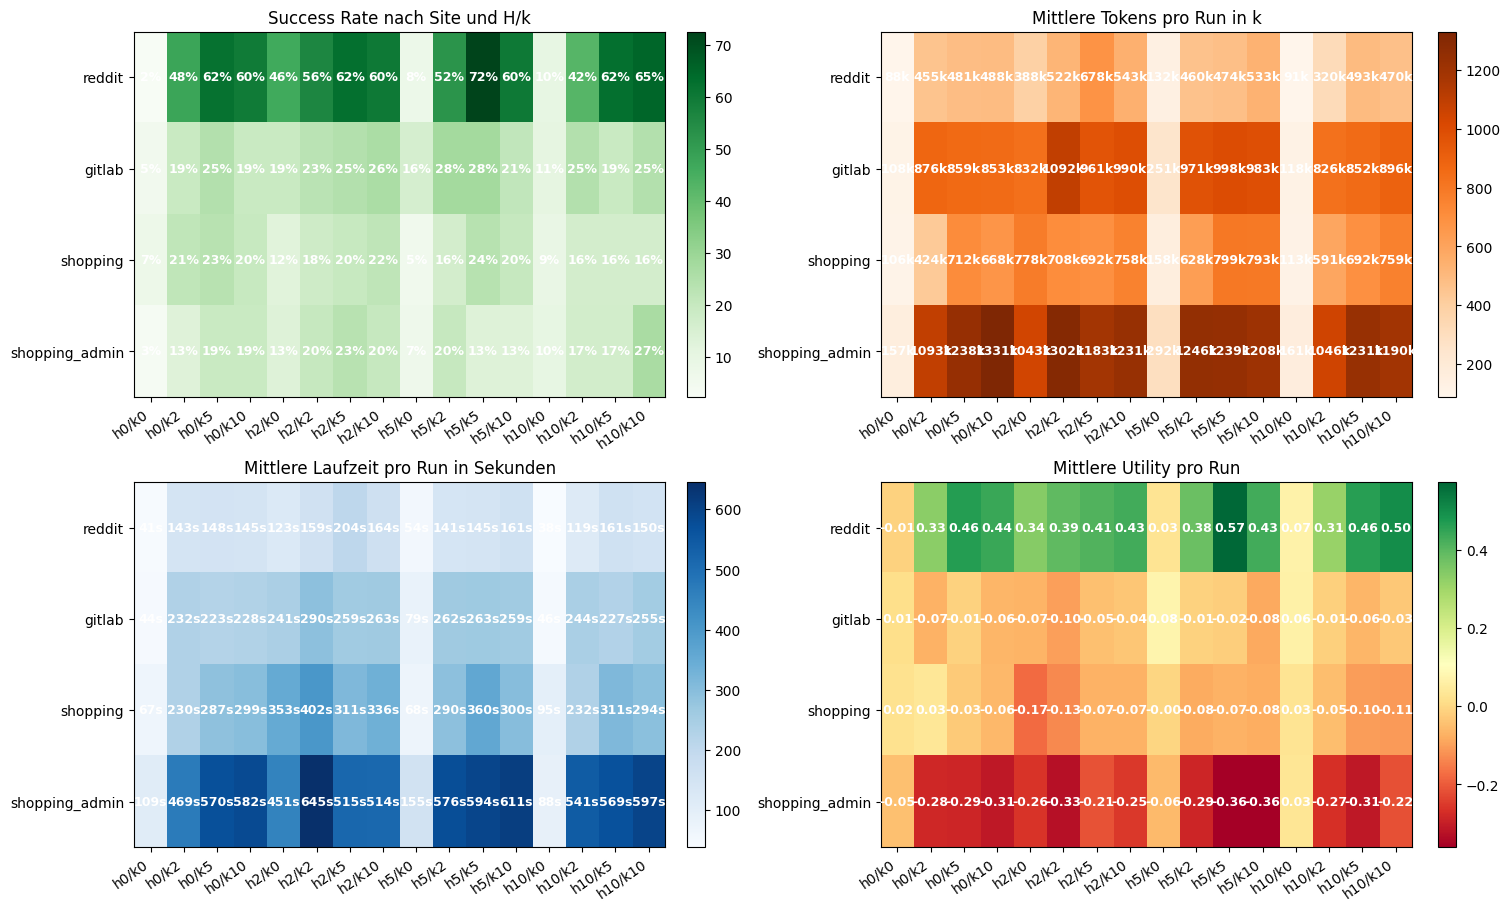

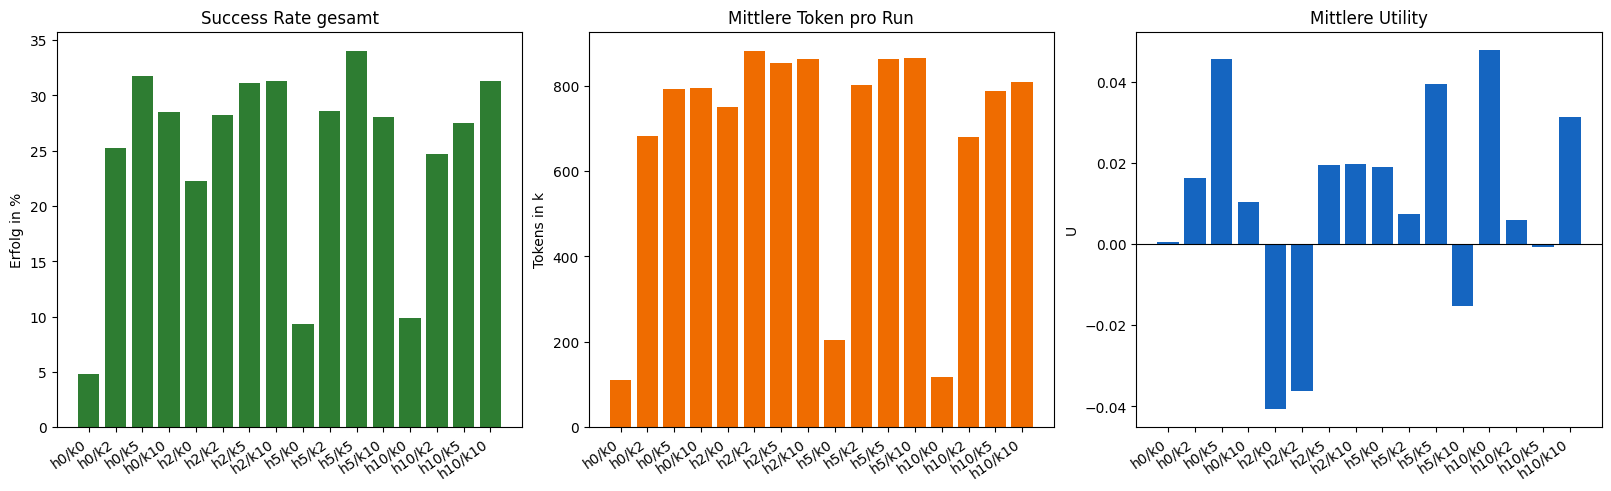

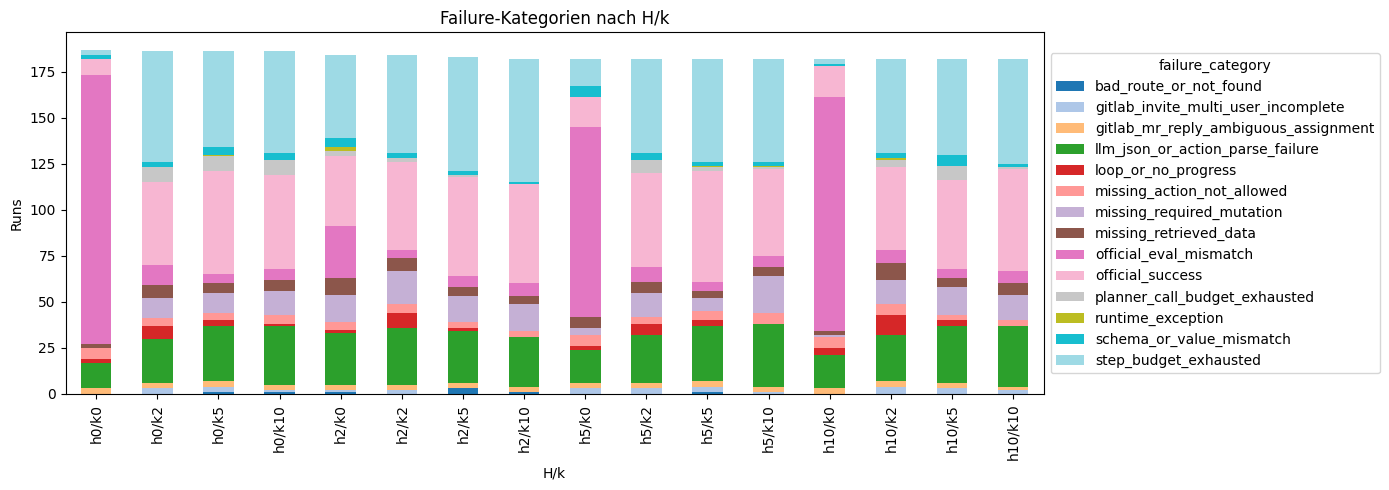

**h2/k2 Detailanalyse:** 132 Fehlschlaege von 184 Runs.

,task_id,site,task_type,task_capability,failure_category,total_steps,total_tokens,runtime_s,runtime_invalid_actions,runtime_loop_events,num_step_errors,last_step_error,output_dir
53,522,gitlab,MUTATE,mutate_gitlab_fork,llm_json_or_action_parse_failure,90.0,2441854.0,846.159,32.0,39.0,30.0,Executor response did not contain a usable JSO...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
69,800,gitlab,MUTATE,mutate_gitlab_group,planner_call_budget_exhausted,80.0,3128271.0,805.082,37.0,49.0,28.0,Action repeats a recent no-progress action; ch...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
85,444,gitlab,MUTATE,mutate_gitlab_file_edit,planner_call_budget_exhausted,77.0,2465557.0,802.266,51.0,41.0,42.0,UI action target looks like a selector or visi...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
117,644,reddit,MUTATE,mutate_forum_post,loop_or_no_progress,6.0,167058.0,45.060,0.0,0.0,0.0,NaN,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
149,505,shopping_admin,MUTATE,mutate_admin_stock,step_budget_exhausted,15.0,572514.0,783.676,4.0,1.0,2.0,timed out,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826,774,shopping_admin,MUTATE,mutate_admin_review_moderation,llm_json_or_action_parse_failure,50.0,157779.0,233.555,47.0,45.0,47.0,Executor response did not contain a usable JSO...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2842,776,shopping_admin,MUTATE,mutate_admin_review_moderation,llm_json_or_action_parse_failure,50.0,1835893.0,680.719,14.0,21.0,13.0,Executor response did not contain a usable JSO...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2858,778,shopping_admin,NAVIGATE,navigate_generic,step_budget_exhausted,50.0,1787601.0,828.796,0.0,6.0,0.0,NaN,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2874,780,shopping_admin,NAVIGATE,navigate_generic,llm_json_or_action_parse_failure,50.0,718385.0,612.617,33.0,33.0,33.0,Executor response did not contain a usable JSO...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...


,failure_category,h2k2_count
0,step_budget_exhausted,53
1,llm_json_or_action_parse_failure,31
2,missing_required_mutation,15
3,loop_or_no_progress,8
4,missing_retrieved_data,7
5,missing_action_not_allowed,5
6,gitlab_mr_reply_ambiguous_assignment,3
7,schema_or_value_mismatch,3
8,official_eval_mismatch,3
9,planner_call_budget_exhausted,2


**Automatische Hinweise fuer bessere h2/k2-Laeufe**

- Executor-Prompt/Candidate-Auswahl weiter schaerfen: mehrere h2/k2-Fehler entstehen, weil das Modell sichtbare Labels, Selektoren oder nicht aktuelle `bid`s nutzt.
- Fuer Shopping-/MUTATE-Runs koennte `--max-steps` testweise von 15 auf 20 oder 25 steigen; h2/k2 plant besser, braucht aber oft mehr Schritte.
- MUTATE-Finalisierung weiter verbessern: vor `SUCCESS` sollte ein sichtbarer Zustand nach der letzten Mutation nochmals aktiv validiert werden.
- Runtime-Replanning staerker machen: bei wiederholtem gleichen URL-/Action-Muster frueher neuen Subgoal verlangen statt weiter im Loop zu bleiben.
- Grounding erweitern: mehr Kandidaten oder fokussierte Kandidaten fuer Formulare, Grid-Zeilen und Produktbuttons in den Prompt aufnehmen.

In [41]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
if not summary_csv.exists():
    print('Summary not found yet:', summary_csv)
else:
    eval_df = pd.read_csv(summary_csv).copy()

    if 'official_success' not in eval_df.columns:
        raise KeyError('official_success fehlt in summary.csv')

    eval_df = apply_analysis_success_columns(eval_df)
    eval_df['success_bool'] = eval_df['official_success_bool']
    success_label = str(eval_df.get('evaluation_success_policy_analysis', pd.Series([SUCCESS_POLICY])).dropna().iloc[-1])
    eval_df['success'] = eval_df['success_bool'].astype(float)
    eval_df['site_category'] = eval_df.get('site', 'unknown').fillna('unknown').astype(str)
    eval_df['hk'] = 'h' + eval_df['h'].astype(str) + '/k' + eval_df['k'].astype(str)
    eval_df['runtime_s'] = eval_df.get('total_runtime_ms', pd.Series(0, index=eval_df.index)).fillna(0) / 1000.0
    eval_df['tokens'] = eval_df.get('total_tokens', pd.Series(0, index=eval_df.index)).fillna(0).astype(float)
    eval_df['tokens_k'] = eval_df['tokens'] / 1_000.0
    eval_df['tokens_m'] = eval_df['tokens'] / 1_000_000.0

    # Gemma MaaS Kostenparameter laut aktueller Experimentannahme.
    # Input/Prompt: 0.15 USD pro 1M Tokens, Output/Completion: 0.60 USD pro 1M Tokens, Cache-Hit: 0.015 USD pro 1M Tokens.
    INPUT_PRICE_PER_1M_USD = 0.15
    OUTPUT_PRICE_PER_1M_USD = 0.60
    CACHE_HIT_PRICE_PER_1M_USD = 0.015
    CACHE_HIT_RATE = 0.0  # Sensitivitaetsparameter: 0.0 = konservativ ohne Cache-Gutschrift.

    # Neue Runs schreiben prompt_tokens/completion_tokens direkt. Alte CSVs fallen transparent auf total_tokens als Input-Approximation zurueck.
    if {'prompt_tokens', 'completion_tokens'}.issubset(eval_df.columns):
        eval_df['input_tokens_est'] = eval_df['prompt_tokens'].fillna(0).astype(float)
        eval_df['output_tokens_est'] = eval_df['completion_tokens'].fillna(0).astype(float)
        missing_split = eval_df['input_tokens_est'].eq(0) & eval_df['output_tokens_est'].eq(0) & eval_df['tokens'].gt(0)
        eval_df.loc[missing_split, 'input_tokens_est'] = eval_df.loc[missing_split, 'tokens']
    else:
        eval_df['input_tokens_est'] = eval_df['tokens']
        eval_df['output_tokens_est'] = 0.0

    eval_df['cache_hit_tokens_est'] = eval_df['input_tokens_est'] * CACHE_HIT_RATE
    eval_df['billable_input_tokens_est'] = eval_df['input_tokens_est'] - eval_df['cache_hit_tokens_est']
    eval_df['estimated_token_cost_usd'] = (
        eval_df['billable_input_tokens_est'] / 1_000_000 * INPUT_PRICE_PER_1M_USD
        + eval_df['output_tokens_est'] / 1_000_000 * OUTPUT_PRICE_PER_1M_USD
        + eval_df['cache_hit_tokens_est'] / 1_000_000 * CACHE_HIT_PRICE_PER_1M_USD
    )

    # Masterarbeits-Utility: Success bleibt dominant, Kosten/Zeit werden normalisiert und klein gewichtet.
    # Bei USE_CONTAMINATION_ADJUSTED_SUCCESS=True nutzt Success die transparente Zusatzmetrik, official_success bleibt unveraendert.
    # ALPHA/BETA sind die Trade-off-Parameter: z.B. 0.05 bedeutet ca. 0.05 Utility-Penalty bei Referenz-Tokens/-laufzeit.
    ALPHA = 0.05
    BETA = 0.05
    TOKEN_REF = eval_df['tokens'].replace(0, np.nan).median()
    RUNTIME_REF_S = eval_df['runtime_s'].replace(0, np.nan).median()
    if not np.isfinite(TOKEN_REF) or TOKEN_REF <= 0:
        TOKEN_REF = 1.0
    if not np.isfinite(RUNTIME_REF_S) or RUNTIME_REF_S <= 0:
        RUNTIME_REF_S = 1.0
    eval_df['token_norm'] = eval_df['tokens'] / TOKEN_REF
    eval_df['runtime_norm'] = eval_df['runtime_s'] / RUNTIME_REF_S
    eval_df['utility'] = eval_df['success'] - (ALPHA * eval_df['token_norm']) - (BETA * eval_df['runtime_norm'])

    key_cols = ['task_id', 'h', 'k']
    eval_df = eval_df.drop_duplicates(key_cols, keep='last')
    planned_keys = None
    if all(name in globals() for name in ['TASK_IDS', 'HS', 'KS']):
        planned_task_ids = [int(x) for x in TASK_IDS]
        planned_hs = [int(x) for x in HS]
        planned_ks = [int(x) for x in KS]
        planned_keys = pd.MultiIndex.from_product(
            [planned_task_ids, planned_hs, planned_ks],
            names=key_cols,
        ).to_frame(index=False)

        observed_keys = eval_df[key_cols].drop_duplicates().assign(observed=True)
        coverage_detail = planned_keys.merge(observed_keys, on=key_cols, how='left')
        coverage_detail['observed'] = coverage_detail['observed'].fillna(False).astype(bool)
        coverage_by_hk = (
            coverage_detail.groupby(['h', 'k'])
            .agg(expected_runs=('task_id', 'count'), observed_runs=('observed', 'sum'))
            .reset_index()
        )
        coverage_by_hk['missing_runs'] = coverage_by_hk['expected_runs'] - coverage_by_hk['observed_runs']
        coverage_by_hk['complete'] = coverage_by_hk['missing_runs'].eq(0)
        display(Markdown('**Coverage-Hinweis:** Die folgende Kosten-/Utility-Auswertung wird auf die aktuelle `TASK_IDS x HS x KS`-Matrix gefiltert. Unvollstaendige H/k-Zellen sind sichtbar und sollten nicht als finaler Vergleich interpretiert werden.'))
        display(coverage_by_hk.sort_values(['h', 'k']))
        eval_df = eval_df.merge(planned_keys, on=key_cols, how='inner')
        hk_order = [f'h{h}/k{k}' for h in planned_hs for k in planned_ks]
    else:
        def hk_sort_key(value):
            try:
                h_part, k_part = str(value).replace('h', '', 1).split('/k', 1)
                return int(h_part), int(k_part)
            except Exception:
                return 999, 999

        hk_order = sorted(eval_df['hk'].dropna().unique(), key=hk_sort_key)

    site_order = ['reddit', 'gitlab', 'shopping', 'shopping_admin']

    def ordered_site_index(frame):
        remaining = [site for site in frame.index if site not in site_order]
        return [site for site in site_order if site in frame.index] + sorted(remaining)

    agg = (
        eval_df.groupby(['site_category', 'h', 'k', 'hk'], dropna=False)
        .agg(
            runs=('task_id', 'count'),
            tasks=('task_id', 'nunique'),
            official_successes=('official_success_bool', 'sum'),
            success_rate=('success', 'mean'),
            mean_score=('official_score', 'mean'),
            total_tokens=('tokens', 'sum'),
            mean_tokens=('tokens', 'mean'),
            mean_tokens_k=('tokens_k', 'mean'),
            mean_input_tokens_k=('input_tokens_est', lambda x: x.mean() / 1000),
            mean_output_tokens_k=('output_tokens_est', lambda x: x.mean() / 1000),
            mean_estimated_token_cost_usd=('estimated_token_cost_usd', 'mean'),
            total_estimated_token_cost_usd=('estimated_token_cost_usd', 'sum'),
            total_runtime_s=('runtime_s', 'sum'),
            mean_runtime_s=('runtime_s', 'mean'),
            mean_steps=('total_steps', 'mean'),
            invalid_actions=('runtime_invalid_actions', 'sum'),
            loop_events=('runtime_loop_events', 'sum'),
            mean_utility=('utility', 'mean'),
            total_utility=('utility', 'sum'),
        )
        .reset_index()
        .sort_values(['site_category', 'h', 'k'])
    )

    display(Markdown(
        f"**Kostenparameter:** Input `${INPUT_PRICE_PER_1M_USD:.3f}`/1M, Output `${OUTPUT_PRICE_PER_1M_USD:.3f}`/1M, Cache-Hit `${CACHE_HIT_PRICE_PER_1M_USD:.3f}`/1M, Cache-Hit-Rate `{CACHE_HIT_RATE:.0%}`. "
        f"**Utility:** `U = Success - {ALPHA:g} * token_norm - {BETA:g} * runtime_norm` "
        f"mit `TOKEN_REF={TOKEN_REF:.0f}` Tokens und `RUNTIME_REF_S={RUNTIME_REF_S:.1f}`. Success-Metrik: `{success_label}`."
    ))

    display_cols = [
        'site_category', 'h', 'k', 'runs', 'tasks', 'official_successes', 'success_rate',
        'mean_score', 'mean_tokens_k', 'mean_input_tokens_k', 'mean_output_tokens_k',
        'mean_estimated_token_cost_usd', 'mean_runtime_s', 'mean_steps',
        'invalid_actions', 'loop_events', 'mean_utility', 'total_utility',
    ]
    display(
        agg[display_cols]
        .style.format({
            'official_successes': '{:.0f}',
            'success_rate': '{:.1%}',
            'mean_score': '{:.2f}',
            'mean_tokens_k': '{:.1f}',
            'mean_runtime_s': '{:.1f}',
            'mean_steps': '{:.1f}',
            'mean_input_tokens_k': '{:.1f}',
            'mean_output_tokens_k': '{:.1f}',
            'mean_estimated_token_cost_usd': '${:.4f}',
            'total_estimated_token_cost_usd': '${:.4f}',
            'invalid_actions': '{:.0f}',
            'loop_events': '{:.0f}',
            'mean_utility': '{:.3f}',
            'total_utility': '{:.3f}',
        })
        .background_gradient(subset=['success_rate', 'mean_utility'], cmap='Greens')
        .background_gradient(subset=['mean_tokens_k', 'mean_estimated_token_cost_usd', 'mean_runtime_s'], cmap='Oranges')
    )

    by_hk = (
        eval_df.groupby(['h', 'k', 'hk'])
        .agg(
            runs=('task_id', 'count'),
            official_successes=('official_success_bool', 'sum'),
            success_rate=('success', 'mean'),
            mean_tokens_k=('tokens_k', 'mean'),
            mean_estimated_token_cost_usd=('estimated_token_cost_usd', 'mean'),
            mean_runtime_s=('runtime_s', 'mean'),
            mean_utility=('utility', 'mean'),
        )
        .reset_index()
        .sort_values(['h', 'k'])
    )
    display(Markdown('**Gesamtvergleich nach H/k**'))
    display(by_hk.style.format({
        'success_rate': '{:.1%}',
        'mean_tokens_k': '{:.1f}',
        'mean_runtime_s': '{:.1f}',
        'mean_estimated_token_cost_usd': '${:.4f}',
        'mean_utility': '{:.3f}',
    }))

    best_by_site = (
        agg.sort_values(['site_category', 'mean_utility'], ascending=[True, False])
        .groupby('site_category', as_index=False)
        .head(1)
        [['site_category', 'hk', 'runs', 'official_successes', 'success_rate', 'mean_tokens_k', 'mean_estimated_token_cost_usd', 'mean_runtime_s', 'mean_utility']]
    )
    display(Markdown('**Beste H/k-Kombination pro Site nach mittlerem Utility**'))
    display(best_by_site.style.format({
        'success_rate': '{:.1%}',
        'mean_tokens_k': '{:.1f}',
        'mean_runtime_s': '{:.1f}',
        'mean_estimated_token_cost_usd': '${:.4f}',
        'mean_utility': '{:.3f}',
    }))

    display(Markdown('**Geschaetzte Tokenkosten nach Site und H/k**'))
    cost_table = agg.pivot_table(index='site_category', columns='hk', values='mean_estimated_token_cost_usd', aggfunc='mean')
    cost_table = cost_table.reindex(index=ordered_site_index(cost_table), columns=[c for c in hk_order if c in cost_table.columns])
    display(cost_table.style.format('${:.4f}').background_gradient(cmap='Oranges'))

    def pivot(metric):
        table = agg.pivot_table(index='site_category', columns='hk', values=metric, aggfunc='mean')
        table = table.reindex(index=ordered_site_index(table), columns=[c for c in hk_order if c in table.columns])
        return table

    def plot_heatmap(ax, data, title, fmt='{:.2f}', cmap='viridis', suffix=''):
        values = data.to_numpy(dtype=float)
        masked = np.ma.masked_invalid(values)
        im = ax.imshow(masked, cmap=cmap, aspect='auto')
        ax.set_title(title)
        ax.set_xticks(range(len(data.columns)))
        ax.set_xticklabels(data.columns, rotation=35, ha='right')
        ax.set_yticks(range(len(data.index)))
        ax.set_yticklabels(data.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if not np.isfinite(values[i, j]):
                    continue
                ax.text(j, i, fmt.format(values[i, j]) + suffix, ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    plot_heatmap(axes[0, 0], pivot('success_rate') * 100, 'Success Rate nach Site und H/k', fmt='{:.0f}', cmap='Greens', suffix='%')
    plot_heatmap(axes[0, 1], pivot('mean_tokens_k'), 'Mittlere Tokens pro Run in k', fmt='{:.0f}', cmap='Oranges', suffix='k')
    plot_heatmap(axes[1, 0], pivot('mean_runtime_s'), 'Mittlere Laufzeit pro Run in Sekunden', fmt='{:.0f}', cmap='Blues', suffix='s')
    plot_heatmap(axes[1, 1], pivot('mean_utility'), 'Mittlere Utility pro Run', fmt='{:.2f}', cmap='RdYlGn')
    plt.show()

    # Erfolgs-/Kostenprofil pro H/k als Balkenplot.
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    x = np.arange(len(by_hk))
    axes[0].bar(x, by_hk['success_rate'] * 100, color='#2e7d32')
    axes[0].set_title('Success Rate gesamt')
    axes[0].set_ylabel('Erfolg in %')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(by_hk['hk'], rotation=35, ha='right')

    axes[1].bar(x, by_hk['mean_tokens_k'], color='#ef6c00')
    axes[1].set_title('Mittlere Token pro Run')
    axes[1].set_ylabel('Tokens in k')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(by_hk['hk'], rotation=35, ha='right')

    axes[2].bar(x, by_hk['mean_utility'], color='#1565c0')
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Mittlere Utility')
    axes[2].set_ylabel('U')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(by_hk['hk'], rotation=35, ha='right')
    plt.show()

    if 'failure_category' in eval_df.columns:
        fail_counts = (
            eval_df.assign(failure_category=eval_df['failure_category'].fillna('unknown'))
            .groupby(['hk', 'failure_category'])
            .size()
            .unstack(fill_value=0)
            .reindex([c for c in hk_order if c in eval_df['hk'].unique()])
        )
        ax = fail_counts.plot(kind='bar', stacked=True, figsize=(14, 5), colormap='tab20')
        ax.set_title('Failure-Kategorien nach H/k')
        ax.set_xlabel('H/k')
        ax.set_ylabel('Runs')
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='failure_category')
        plt.tight_layout()
        plt.show()

    # Detailblick: Was verhindert h2/k2 noch?
    h2k2_failures = eval_df[(eval_df['h'].eq(2)) & (eval_df['k'].eq(2)) & (eval_df['success'].eq(0))].copy()
    display(Markdown(f'**h2/k2 Detailanalyse:** {len(h2k2_failures)} Fehlschlaege von {len(eval_df[(eval_df["h"].eq(2)) & (eval_df["k"].eq(2))])} Runs.'))
    if not h2k2_failures.empty:
        detail_cols = [
            'task_id', 'site', 'task_type', 'task_capability', 'failure_category',
            'total_steps', 'total_tokens', 'runtime_s', 'runtime_invalid_actions',
            'runtime_loop_events', 'num_step_errors', 'last_step_error', 'output_dir'
        ]
        display(h2k2_failures[[c for c in detail_cols if c in h2k2_failures.columns]])
        display(h2k2_failures['failure_category'].fillna('unknown').value_counts().rename_axis('failure_category').reset_index(name='h2k2_count'))

        recommendations = []
        if h2k2_failures['failure_category'].astype(str).str.contains('llm_json_or_action_parse_failure', na=False).any():
            recommendations.append('- Executor-Prompt/Candidate-Auswahl weiter schaerfen: mehrere h2/k2-Fehler entstehen, weil das Modell sichtbare Labels, Selektoren oder nicht aktuelle `bid`s nutzt.')
        if h2k2_failures['failure_category'].astype(str).str.contains('step_budget_exhausted', na=False).any():
            recommendations.append('- Fuer Shopping-/MUTATE-Runs koennte `--max-steps` testweise von 15 auf 20 oder 25 steigen; h2/k2 plant besser, braucht aber oft mehr Schritte.')
        if h2k2_failures['failure_category'].astype(str).str.contains('missing_required_mutation', na=False).any():
            recommendations.append('- MUTATE-Finalisierung weiter verbessern: vor `SUCCESS` sollte ein sichtbarer Zustand nach der letzten Mutation nochmals aktiv validiert werden.')
        if h2k2_failures['failure_category'].astype(str).str.contains('loop_or_no_progress', na=False).any():
            recommendations.append('- Runtime-Replanning staerker machen: bei wiederholtem gleichen URL-/Action-Muster frueher neuen Subgoal verlangen statt weiter im Loop zu bleiben.')
        if h2k2_failures.get('runtime_invalid_actions', pd.Series(0, index=h2k2_failures.index)).fillna(0).sum() > 0:
            recommendations.append('- Grounding erweitern: mehr Kandidaten oder fokussierte Kandidaten fuer Formulare, Grid-Zeilen und Produktbuttons in den Prompt aufnehmen.')
        display(Markdown('**Automatische Hinweise fuer bessere h2/k2-Laeufe**\n\n' + '\n'.join(recommendations)))


## 8. Near-Miss- und Fehlerklassenanalyse

Diese Zelle nutzt den korrigierten `official_success` aus der Summary. Transparente, nachvollziehbare Evaluator-Korrekturen wie eindeutige URL-/Referer-Normalisierung zaehlen damit direkt als offizieller Erfolg in dieser Auswertung; der rohe WebArena-Wert bleibt als `official_success_raw` dokumentiert. Zusaetzlich wird ein diagnostischer `near_miss_score` aus den lokalen Run-Diagnosen gelesen oder mit der aktuellen Diagnose-Logik neu berechnet.

Wichtig: Near-Miss ist eine Erklaerungsmetrik fuer Runs, die auch nach dieser transparenten Korrektur nicht erfolgreich sind. Fuer die Sensitivitaetsanalyse werden zusaetzlich TIT-artige Schwellen (`near_miss_score >= 0.90/0.80/0.70/0.60`) berechnet. So sieht man getrennt, wie streng oder grosszuegig ein diagnostischer Teilerfolg als Treffer gelesen wuerde.


**Near-Miss-Ueberblick**  \nRuns: `2934` | official successes: `727` | failed/diagnostic rows: `2207`.  \n`near_miss_score` erklaert verbleibende Fehler nach korrigiertem `official_success`; raw Wert bleibt als `official_success_raw` sichtbar.

**Near-Miss-Baender nach Site**

,site_category,near_miss_band,runs,official_successes,mean_near_miss,mean_steps,mean_tokens_k,mean_runtime_s
1,gitlab,official_success,190,190,1.00,9.4,226.6,79.6
0,gitlab,high_near_miss,66,0,0.90,22.6,960.5,268.0
3,gitlab,substantial_near_miss,145,0,0.69,11.6,417.8,119.6
2,gitlab,partial_progress,460,0,0.45,27.5,1003.5,268.5
4,gitlab,weak_progress,51,0,0.27,43.4,1606.1,412.1
7,reddit,official_success,312,312,1.00,8.6,242.9,75.8
5,reddit,high_near_miss,1,0,0.95,5.0,73.0,35.5
9,reddit,substantial_near_miss,64,0,0.74,11.8,366.3,111.2
8,reddit,partial_progress,240,0,0.44,17.1,565.5,181.2
10,reddit,weak_progress,32,0,0.26,33.9,1050.8,335.8


**Near-Miss-Utility und TIT-Schwellen**  
Kontinuierlich: `U_score = near_miss_score - 0.05 * token_norm - 0.05 * runtime_norm`.  
TIT-Schwellen: `near_miss_score >= 90/80/70/60%`, jeweils mit derselben Penalty. `TOKEN_REF=274230`, `RUNTIME_REF_S=111.7`.

,site_category,h,k,runs,official_success_rate,mean_near_miss_score,mean_score_utility,mean_tokens_k,mean_runtime_s,tit_90_rate,tit_80_rate,tit_70_rate,tit_60_rate,mean_tit_90_utility,mean_tit_80_utility,mean_tit_70_utility,mean_tit_60_utility
0,gitlab,0,0,57,5.3%,0.50,0.464,107.7,43.9,7.0%,10.5%,10.5%,10.5%,0.031,0.066,0.066,0.066
1,gitlab,0,2,57,19.3%,0.62,0.359,875.8,231.9,28.1%,28.1%,40.4%,40.4%,0.017,0.017,0.140,0.140
2,gitlab,0,5,57,24.6%,0.66,0.408,858.6,223.4,33.3%,35.1%,49.1%,49.1%,0.077,0.094,0.235,0.235
3,gitlab,0,10,57,19.3%,0.61,0.348,852.6,228.0,24.6%,24.6%,38.6%,40.4%,-0.012,-0.012,0.128,0.146
4,gitlab,2,0,57,19.3%,0.62,0.357,831.6,240.7,24.6%,24.6%,38.6%,40.4%,-0.014,-0.014,0.127,0.144
5,gitlab,2,2,57,22.8%,0.62,0.288,1091.9,290.0,28.1%,28.1%,36.8%,38.6%,-0.048,-0.048,0.040,0.057
6,gitlab,2,5,57,24.6%,0.63,0.342,960.9,258.7,26.3%,28.1%,43.9%,45.6%,-0.028,-0.010,0.148,0.165
7,gitlab,2,10,57,26.3%,0.64,0.345,990.2,263.1,28.1%,31.6%,43.9%,45.6%,-0.018,0.017,0.140,0.158
8,gitlab,5,0,57,15.8%,0.62,0.543,251.4,79.4,24.6%,29.8%,38.6%,38.6%,0.164,0.217,0.305,0.305
9,gitlab,5,2,57,28.1%,0.68,0.385,971.1,262.1,36.8%,38.6%,52.6%,52.6%,0.074,0.092,0.232,0.232


**Near-Miss/TIT-Gesamtvergleich nach H/k**

,h,k,hk,runs,official_success_rate,mean_near_miss_score,mean_score_utility,tit_90_rate,tit_80_rate,tit_70_rate,tit_60_rate,mean_tit_90_utility,mean_tit_80_utility,mean_tit_70_utility,mean_tit_60_utility
0,0,0,h0/k0,187,4.8%,0.47,0.423,5.9%,8.0%,8.6%,9.6%,0.011,0.033,0.038,0.049
1,0,2,h0/k2,186,25.3%,0.61,0.378,28.5%,29.6%,39.2%,39.8%,0.048,0.059,0.156,0.161
2,0,5,h0/k5,186,31.7%,0.64,0.372,35.5%,38.2%,46.8%,46.8%,0.083,0.110,0.196,0.196
3,0,10,h0/k10,186,28.5%,0.63,0.351,31.2%,33.9%,44.1%,45.2%,0.037,0.064,0.166,0.177
4,2,0,h2/k0,184,22.3%,0.59,0.328,24.5%,27.2%,39.7%,40.2%,-0.019,0.008,0.133,0.139
5,2,2,h2/k2,184,28.3%,0.64,0.318,31.0%,32.1%,45.7%,46.7%,-0.009,0.002,0.138,0.149
6,2,5,h2/k5,183,31.1%,0.64,0.344,32.2%,35.0%,44.8%,45.4%,0.030,0.058,0.156,0.162
7,2,10,h2/k10,182,31.3%,0.64,0.344,31.9%,35.2%,45.1%,46.2%,0.025,0.058,0.157,0.168
8,5,0,h5/k0,182,9.3%,0.53,0.456,14.3%,18.1%,22.5%,23.6%,0.069,0.107,0.151,0.162
9,5,2,h5/k2,182,28.6%,0.64,0.358,32.4%,33.5%,44.5%,44.5%,0.046,0.057,0.167,0.167


**Beste H/k-Kombination pro Site nach Near-Miss-Score-Utility**

,site_category,hk,runs,official_success_rate,mean_near_miss_score,mean_score_utility,tit_90_rate,tit_80_rate,tit_70_rate,tit_60_rate
8,gitlab,h5/k0,57,15.8%,0.62,0.543,24.6%,29.8%,38.6%,38.6%
31,reddit,h10/k10,40,65.0%,0.84,0.689,65.0%,65.0%,75.0%,77.5%
40,shopping,h5/k0,55,5.5%,0.50,0.442,9.1%,16.4%,20.0%,21.8%
60,shopping_admin,h10/k0,30,10.0%,0.47,0.398,10.0%,10.0%,10.0%,10.0%


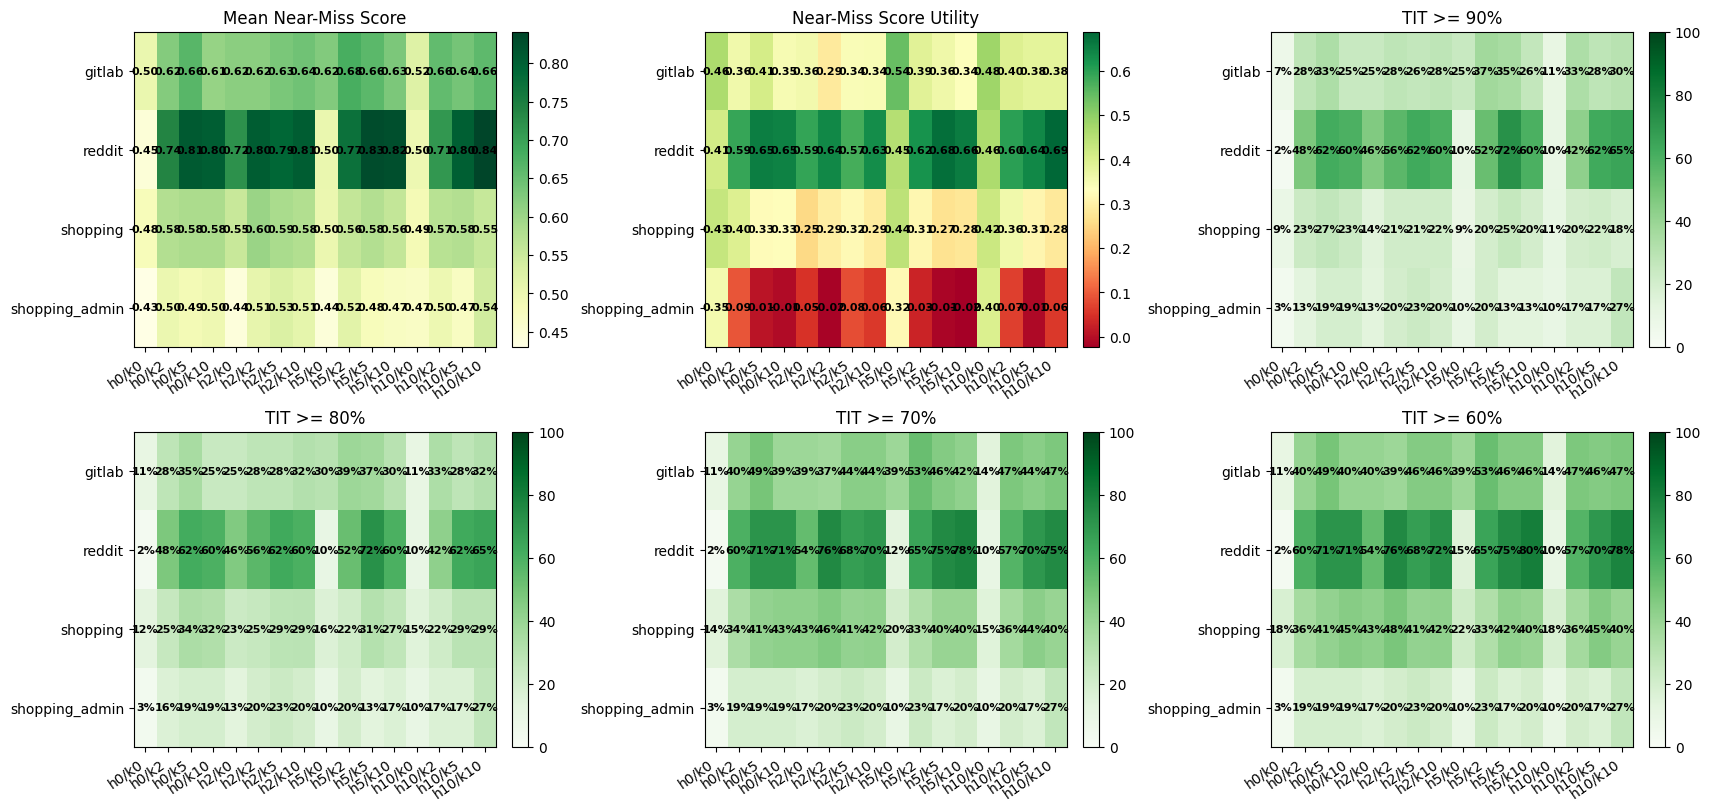

**Fehlerklassen nach Capability**

,site_category,task_capability,failure_category_analysis,runs,official_successes,mean_near_miss,max_near_miss,mean_steps
0,gitlab,mutate_generic,gitlab_invite_multi_user_incomplete,9,0,0.91,1.00,41.3
2,gitlab,mutate_generic,missing_required_mutation,17,0,0.74,0.75,14.8
3,gitlab,mutate_generic,official_eval_mismatch,10,0,0.45,0.45,3.7
4,gitlab,mutate_generic,step_budget_exhausted,11,0,0.40,0.45,40.9
1,gitlab,mutate_generic,llm_json_or_action_parse_failure,1,0,0.30,0.30,50.0
8,gitlab,mutate_gitlab_file_edit,step_budget_exhausted,21,0,0.45,0.45,49.7
6,gitlab,mutate_gitlab_file_edit,official_eval_mismatch,8,0,0.45,0.45,4.2
7,gitlab,mutate_gitlab_file_edit,planner_call_budget_exhausted,8,0,0.40,0.40,34.1
5,gitlab,mutate_gitlab_file_edit,llm_json_or_action_parse_failure,11,0,0.30,0.30,50.0
10,gitlab,mutate_gitlab_fork,missing_required_mutation,2,0,0.75,0.75,13.0


**Top-Near-Misses unter den verbleibenden Analysefehlern**

,task_id,h,k,site_category,task_type,task_capability,failure_category_analysis,near_miss_band,near_miss_score,total_steps,tokens_k,runtime_s,final_response_status,mutation_action_count,finish_after_mutation_action,output_dir
1285,578,2,2,gitlab,MUTATE,mutate_gitlab_members,gitlab_invite_multi_user_incomplete,high_near_miss,1.00,28,1284.4,316.9,SUCCESS,23,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/gitlab/578/h2_k2/578
595,747,0,10,gitlab,MUTATE,mutate_generic,gitlab_invite_multi_user_incomplete,high_near_miss,1.00,13,483.2,107.7,SUCCESS,10,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/gitlab/747/h0_k10/747
168,15,5,0,shopping_admin,RETRIEVE,retrieve_aggregate,schema_or_value_mismatch,high_near_miss,0.95,4,119.8,35.8,SUCCESS,2,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/shopping_admin/15/h5_k0/15
1612,29,5,0,reddit,RETRIEVE,retrieve_visible_or_multi_page,schema_or_value_mismatch,high_near_miss,0.95,5,73.0,35.5,SUCCESS,0,False,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/29/h5_k0/29
2083,50,0,5,shopping,RETRIEVE,retrieve_shopping_order_aggregate,schema_or_value_mismatch,high_near_miss,0.95,22,856.0,248.3,SUCCESS,11,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/shopping/50/h0_k5/50
2086,50,2,2,shopping,RETRIEVE,retrieve_shopping_order_aggregate,schema_or_value_mismatch,high_near_miss,0.95,8,345.2,120.9,SUCCESS,1,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/shopping/50/h2_k2/50
2089,50,5,0,shopping,RETRIEVE,retrieve_shopping_order_aggregate,schema_or_value_mismatch,high_near_miss,0.95,5,185.9,53.3,SUCCESS,1,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/shopping/50/h5_k0/50
2117,124,2,0,shopping,RETRIEVE,retrieve_shopping_price_range,schema_or_value_mismatch,high_near_miss,0.95,16,652.7,231.0,SUCCESS,4,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/shopping/124/h2_k0/124
2118,124,2,2,shopping,RETRIEVE,retrieve_shopping_price_range,schema_or_value_mismatch,high_near_miss,0.95,12,444.9,150.8,SUCCESS,2,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/shopping/124/h2_k2/124
2127,124,10,5,shopping,RETRIEVE,retrieve_shopping_price_range,schema_or_value_mismatch,high_near_miss,0.95,10,361.0,174.5,SUCCESS,3,True,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/shopping/124/h10_k5/124


**Interpretation der beobachteten Fehlerklassen**

,failure_category_analysis,runs,failed_runs,mean_near_miss,interpretation
13,step_budget_exhausted,738,738,0.43,"Run hat Budget verbraucht. Mehr Steps helfen nur, wenn der Trace Fortschritt zeigt; bei Loops braucht es Routing/Recovery statt nur mehr Budget."
8,official_eval_mismatch,475,475,0.49,"Strukturell abgeschlossen, aber offizieller Evaluator lehnt Inhalt/Ziel ab. HAR und eval_result pruefen."
3,llm_json_or_action_parse_failure,428,428,0.30,"Ausgabeformat/Action-JSON instabil. Besser durch kuerzere Prompts, strengere Output-Regeln oder Executor-Guards."
6,missing_required_mutation,161,161,0.74,"Agent meldet Erfolg, aber HAR enthaelt nicht den offiziell erwarteten POST/PUT. Meist falsches Ziel, falscher Submit oder nur UI-Zustand ohne evaluierten State-Change."
7,missing_retrieved_data,85,85,0.70,"Nicht standardisierte Fehlerklasse; Trace, HAR und eval_result manuell pruefen."
5,missing_action_not_allowed,73,73,0.56,"Nicht standardisierte Fehlerklasse; Trace, HAR und eval_result manuell pruefen."
4,loop_or_no_progress,55,55,0.45,"Wiederholung ohne Fortschritt. Recovery-Regeln, stale-bid-refresh oder Seitenreset koennen helfen."
10,planner_call_budget_exhausted,53,53,0.40,Planungsbudget leer. Dynamische Replanung oder kompaktere Repair-Briefs koennen helfen.
12,schema_or_value_mismatch,50,50,0.94,"Nicht standardisierte Fehlerklasse; Trace, HAR und eval_result manuell pruefen."
2,gitlab_mr_reply_ambiguous_assignment,47,47,0.62,"GitLab-MR-Reply-Sonderklasse: richtige Workflow-Idee, aber MR-Zuordnung ueber kurze Topic-Phrase ist mehrdeutig. Verbesserung eher durch Executor-Routing/Assignment-Kontext als durch mehr Steps."


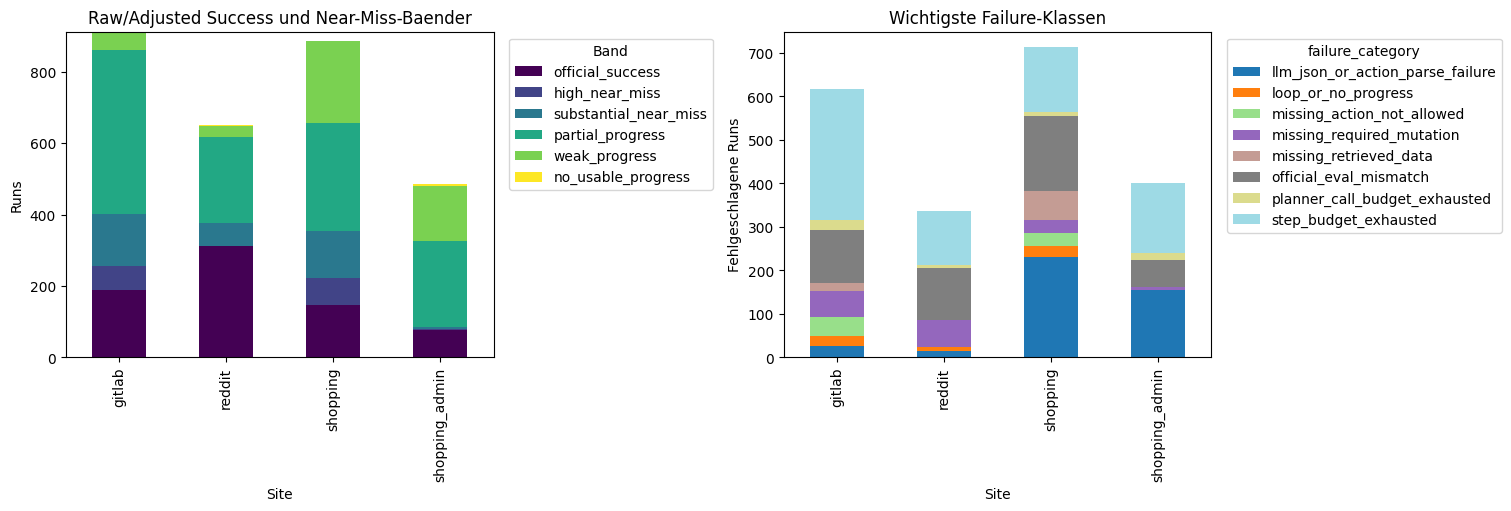

**Ableitbare Verbesserungsrichtungen**

- GitLab MR Reply getrennt ausweisen: Fehler entstehen oft durch mehrdeutige Topic-Suche und falsche MR-Auswahl; weitere Verbesserungen waeren eher Executor-Routing/Assignment-Kontext als mehr Step-Budget.
- MUTATE-Finalisierung staerken: SUCCESS erst nach sichtbarer Bestaetigung plus erwartetem Submit-/State-Change-Indiz erlauben.
- Prompt/Output stabilisieren: kuerzere Repair-Briefs, klarere JSON-Regeln und keine grossen HTML-/Code-Dumps in Actions.
- Bei Step-Budget/Loops nicht pauschal mehr Steps geben: zuerst Trace pruefen, dann Recovery-Regel oder Kandidatenpriorisierung verbessern.

In [42]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))

try:
    from hk_agent.diagnostics import diagnose_run_summary
except Exception as exc:
    diagnose_run_summary = None
    print('diagnose_run_summary konnte nicht importiert werden:', exc)

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
if not summary_csv.exists():
    print('Summary not found yet:', summary_csv)
else:
    near_df = pd.read_csv(summary_csv).copy()

    def as_bool(series):
        return series.fillna(False).astype(str).str.lower().isin({'true', '1', 'yes', 'success'})

    def safe_float(value, default=np.nan):
        try:
            if pd.isna(value):
                return default
            return float(value)
        except Exception:
            return default

    def load_json(path):
        try:
            return json.loads(Path(path).read_text())
        except Exception:
            return None

    def recompute_or_load_diagnostic(row):
        output_dir = Path(str(row.get('output_dir') or ''))
        diagnostic_path = output_dir / 'diagnostic.json'
        run_summary_path = output_dir / 'run_summary.json'

        if diagnose_run_summary is not None and run_summary_path.exists():
            run_summary = load_json(run_summary_path)
            if isinstance(run_summary, dict):
                try:
                    return diagnose_run_summary(run_summary, output_dir)
                except Exception as exc:
                    return {
                        'failure_category': row.get('failure_category', 'diagnostic_recompute_failed'),
                        'failure_notes': f'Diagnostic recompute failed: {exc}',
                        'diagnostic_completion': row.get('diagnostic_completion', np.nan),
                    }

        existing = load_json(diagnostic_path)
        if isinstance(existing, dict):
            return existing

        return {
            'failure_category': row.get('failure_category', 'unknown'),
            'failure_notes': row.get('failure_notes', ''),
            'diagnostic_completion': row.get('diagnostic_completion', np.nan),
            'official_success': row.get('official_success', False),
        }

    if 'official_success' not in near_df.columns:
        raise KeyError('official_success fehlt in summary.csv')

    key_cols = ['task_id', 'h', 'k']
    if all(col in near_df.columns for col in key_cols):
        near_df = near_df.drop_duplicates(key_cols, keep='last')
    near_df = apply_analysis_success_columns(near_df)
    analysis_success_label = str(near_df.get('evaluation_success_policy_analysis', pd.Series([SUCCESS_POLICY])).dropna().iloc[-1])

    diagnostics = [recompute_or_load_diagnostic(row) for _, row in near_df.iterrows()]
    diag_df = pd.DataFrame(diagnostics)
    for col in ['failure_category', 'failure_notes', 'diagnostic_completion', 'task_capability', 'capability_tier']:
        if col in diag_df.columns:
            near_df[f'diag_{col}'] = diag_df[col].values

    if 'diag_failure_category' in near_df.columns:
        near_df['failure_category_analysis'] = near_df['diag_failure_category'].fillna(near_df.get('failure_category', 'unknown'))
    else:
        near_df['failure_category_analysis'] = near_df.get('failure_category', pd.Series('unknown', index=near_df.index)).fillna('unknown')

    if 'diag_failure_notes' in near_df.columns:
        near_df['failure_notes_analysis'] = near_df['diag_failure_notes'].fillna('')
    else:
        near_df['failure_notes_analysis'] = near_df.get('failure_notes', pd.Series('', index=near_df.index)).fillna('')

    completion_source = near_df.get('diag_diagnostic_completion', near_df.get('diagnostic_completion', pd.Series(np.nan, index=near_df.index)))
    near_df['near_miss_score'] = pd.to_numeric(completion_source, errors='coerce')
    near_df.loc[near_df['analysis_success_bool'], 'near_miss_score'] = 1.0
    near_df['near_miss_score'] = near_df['near_miss_score'].fillna(0.0).clip(0, 1)

    def near_band(row):
        if row['official_success_bool']:
            return 'official_success'
        if row['analysis_success_bool']:
            return 'adjusted_success'
        score = row['near_miss_score']
        if score >= 0.80:
            return 'high_near_miss'
        if score >= 0.55:
            return 'substantial_near_miss'
        if score >= 0.35:
            return 'partial_progress'
        if score > 0:
            return 'weak_progress'
        return 'no_usable_progress'

    near_df['near_miss_band'] = near_df.apply(near_band, axis=1)
    near_df['site_category'] = near_df.get('site', pd.Series('unknown', index=near_df.index)).fillna('unknown').astype(str)
    near_df['runtime_s'] = near_df.get('total_runtime_ms', pd.Series(0, index=near_df.index)).fillna(0).astype(float) / 1000.0
    near_df['tokens'] = near_df.get('total_tokens', pd.Series(0, index=near_df.index)).fillna(0).astype(float)
    near_df['tokens_k'] = near_df['tokens'] / 1000.0

    interpretation_map = {
        'official_success': 'Raw offiziell geloest; kann als Benchmark-Erfolg gezaehlt werden.',
        'adjusted_success': 'Transparent korrigierter Erfolg; raw official_success_raw bleibt sichtbar, official_success zaehlt fuer die Auswertung.',
        'contamination_suffix_near_miss': 'Zielzustand wirkt korrekt, aber ein Suffix/Altzustand aus fehlendem Reset verhindert die offizielle Wertung. Nur als transparente Zusatzdiagnose nutzen.',
        'gitlab_mr_reply_ambiguous_assignment': 'GitLab-MR-Reply-Sonderklasse: richtige Workflow-Idee, aber MR-Zuordnung ueber kurze Topic-Phrase ist mehrdeutig. Verbesserung eher durch Executor-Routing/Assignment-Kontext als durch mehr Steps.',
        'missing_required_mutation': 'Agent meldet Erfolg, aber HAR enthaelt nicht den offiziell erwarteten POST/PUT. Meist falsches Ziel, falscher Submit oder nur UI-Zustand ohne evaluierten State-Change.',
        'premature_mutation_success': 'Zu frueh SUCCESS gemeldet. Prompt/Validator sollte finalen State-Check und echte Mutation erzwingen.',
        'step_budget_exhausted': 'Run hat Budget verbraucht. Mehr Steps helfen nur, wenn der Trace Fortschritt zeigt; bei Loops braucht es Routing/Recovery statt nur mehr Budget.',
        'planner_call_budget_exhausted': 'Planungsbudget leer. Dynamische Replanung oder kompaktere Repair-Briefs koennen helfen.',
        'llm_json_or_action_parse_failure': 'Ausgabeformat/Action-JSON instabil. Besser durch kuerzere Prompts, strengere Output-Regeln oder Executor-Guards.',
        'loop_or_no_progress': 'Wiederholung ohne Fortschritt. Recovery-Regeln, stale-bid-refresh oder Seitenreset koennen helfen.',
        'bad_route_or_not_found': 'Falsche Route oder 404. Site-spezifische URL-Konventionen/Link-Priorisierung verbessern.',
        'official_eval_mismatch': 'Strukturell abgeschlossen, aber offizieller Evaluator lehnt Inhalt/Ziel ab. HAR und eval_result pruefen.',
        'runtime_exception': 'Technischer Lauf- oder Servicefehler; nicht als Agent-Faehigkeit interpretieren.',
    }
    near_df['near_miss_interpretation'] = near_df['failure_category_analysis'].map(interpretation_map).fillna(
        'Nicht standardisierte Fehlerklasse; Trace, HAR und eval_result manuell pruefen.'
    )

    failed = near_df[~near_df['official_success_bool']].copy()
    display(Markdown(
        f'**Near-Miss-Ueberblick**  \\n'
        f'Runs: `{len(near_df)}` | official successes: `{int(near_df["official_success_bool"].sum())}` | '
        f'failed/diagnostic rows: `{len(failed)}`.  \\n'
        '`near_miss_score` erklaert verbleibende Fehler nach korrigiertem `official_success`; raw Wert bleibt als `official_success_raw` sichtbar.'
    ))

    band_order = ['official_success', 'adjusted_success', 'high_near_miss', 'substantial_near_miss', 'partial_progress', 'weak_progress', 'no_usable_progress']
    band_summary = (
        near_df.groupby(['site_category', 'near_miss_band'])
        .agg(
            runs=('task_id', 'count'),
            official_successes=('official_success_bool', 'sum'),
            mean_near_miss=('near_miss_score', 'mean'),
            mean_steps=('total_steps', 'mean'),
            mean_tokens_k=('tokens_k', 'mean'),
            mean_runtime_s=('runtime_s', 'mean'),
        )
        .reset_index()
    )
    band_summary['near_miss_band'] = pd.Categorical(band_summary['near_miss_band'], categories=band_order, ordered=True)
    display(Markdown('**Near-Miss-Baender nach Site**'))
    display(
        band_summary.sort_values(['site_category', 'near_miss_band']).style.format({
            'runs': '{:.0f}',
            'official_successes': '{:.0f}',
            'mean_near_miss': '{:.2f}',
            'mean_steps': '{:.1f}',
            'mean_tokens_k': '{:.1f}',
            'mean_runtime_s': '{:.1f}',
        }).background_gradient(subset=['mean_near_miss'], cmap='YlGn')
    )

    # Near-Miss-Utility: gleiche Kosten-/Zeitlogik wie Abschnitt 7, aber mit diagnostischem Score.
    NEAR_MISS_TIT_THRESHOLDS = [0.90, 0.80, 0.70, 0.60]
    NEAR_ALPHA = globals().get('ALPHA', 0.05)
    NEAR_BETA = globals().get('BETA', 0.05)
    NEAR_TOKEN_REF = globals().get('TOKEN_REF', near_df['tokens'].replace(0, np.nan).median())
    NEAR_RUNTIME_REF_S = globals().get('RUNTIME_REF_S', near_df['runtime_s'].replace(0, np.nan).median())
    if not np.isfinite(NEAR_TOKEN_REF) or NEAR_TOKEN_REF <= 0:
        NEAR_TOKEN_REF = 1.0
    if not np.isfinite(NEAR_RUNTIME_REF_S) or NEAR_RUNTIME_REF_S <= 0:
        NEAR_RUNTIME_REF_S = 1.0

    near_df['near_token_norm'] = near_df['tokens'] / NEAR_TOKEN_REF
    near_df['near_runtime_norm'] = near_df['runtime_s'] / NEAR_RUNTIME_REF_S
    near_df['near_cost_penalty'] = (NEAR_ALPHA * near_df['near_token_norm']) + (NEAR_BETA * near_df['near_runtime_norm'])
    near_df['near_miss_score_utility'] = near_df['near_miss_score'] - near_df['near_cost_penalty']

    tit_cols = []
    tit_utility_cols = []
    for threshold in NEAR_MISS_TIT_THRESHOLDS:
        pct = int(round(threshold * 100))
        tit_col = f'tit_{pct}'
        utility_col = f'tit_{pct}_utility'
        tit_cols.append(tit_col)
        tit_utility_cols.append(utility_col)
        near_df[tit_col] = near_df['near_miss_score'].ge(threshold).astype(float)
        near_df[utility_col] = near_df[tit_col] - near_df['near_cost_penalty']

    if 'h' in near_df.columns and 'k' in near_df.columns:
        near_df['hk'] = 'h' + near_df['h'].astype(str) + '/k' + near_df['k'].astype(str)
    else:
        near_df['hk'] = 'unknown'

    near_utility_agg = (
        near_df.groupby(['site_category', 'h', 'k', 'hk'], dropna=False)
        .agg(
            runs=('task_id', 'count'),
            official_success_rate=('official_success_bool', 'mean'),
            mean_near_miss_score=('near_miss_score', 'mean'),
            mean_score_utility=('near_miss_score_utility', 'mean'),
            mean_tokens_k=('tokens_k', 'mean'),
            mean_runtime_s=('runtime_s', 'mean'),
            **{f'{col}_rate': (col, 'mean') for col in tit_cols},
            **{f'mean_{col}': (col, 'mean') for col in tit_utility_cols},
        )
        .reset_index()
        .sort_values(['site_category', 'h', 'k'])
    )

    display(Markdown(
        f'**Near-Miss-Utility und TIT-Schwellen**  \n'
        f'Kontinuierlich: `U_score = near_miss_score - {NEAR_ALPHA:g} * token_norm - {NEAR_BETA:g} * runtime_norm`.  \n'
        f'TIT-Schwellen: `near_miss_score >= 90/80/70/60%`, jeweils mit derselben Penalty. '
        f'`TOKEN_REF={NEAR_TOKEN_REF:.0f}`, `RUNTIME_REF_S={NEAR_RUNTIME_REF_S:.1f}`.'
    ))

    near_display_cols = [
        'site_category', 'h', 'k', 'runs', 'official_success_rate', 'mean_near_miss_score',
        'mean_score_utility', 'mean_tokens_k', 'mean_runtime_s',
    ]
    near_display_cols += [f'{col}_rate' for col in tit_cols]
    near_display_cols += [f'mean_{col}' for col in tit_utility_cols]
    display(
        near_utility_agg[near_display_cols].style.format({
            'official_success_rate': '{:.1%}',
            'mean_near_miss_score': '{:.2f}',
            'mean_score_utility': '{:.3f}',
            'mean_tokens_k': '{:.1f}',
            'mean_runtime_s': '{:.1f}',
            **{f'{col}_rate': '{:.1%}' for col in tit_cols},
            **{f'mean_{col}': '{:.3f}' for col in tit_utility_cols},
        })
        .background_gradient(subset=['mean_near_miss_score', 'mean_score_utility'], cmap='YlGn')
        .background_gradient(subset=[f'{col}_rate' for col in tit_cols], cmap='Greens')
        .background_gradient(subset=[f'mean_{col}' for col in tit_utility_cols], cmap='RdYlGn')
    )

    near_by_hk = (
        near_df.groupby(['h', 'k', 'hk'], dropna=False)
        .agg(
            runs=('task_id', 'count'),
            official_success_rate=('official_success_bool', 'mean'),
            mean_near_miss_score=('near_miss_score', 'mean'),
            mean_score_utility=('near_miss_score_utility', 'mean'),
            **{f'{col}_rate': (col, 'mean') for col in tit_cols},
            **{f'mean_{col}': (col, 'mean') for col in tit_utility_cols},
        )
        .reset_index()
        .sort_values(['h', 'k'])
    )
    display(Markdown('**Near-Miss/TIT-Gesamtvergleich nach H/k**'))
    display(near_by_hk.style.format({
        'official_success_rate': '{:.1%}',
        'mean_near_miss_score': '{:.2f}',
        'mean_score_utility': '{:.3f}',
        **{f'{col}_rate': '{:.1%}' for col in tit_cols},
        **{f'mean_{col}': '{:.3f}' for col in tit_utility_cols},
    }))

    best_near_by_site = (
        near_utility_agg.sort_values(['site_category', 'mean_score_utility'], ascending=[True, False])
        .groupby('site_category', as_index=False)
        .head(1)
        [['site_category', 'hk', 'runs', 'official_success_rate', 'mean_near_miss_score', 'mean_score_utility'] + [f'{col}_rate' for col in tit_cols]]
    )
    display(Markdown('**Beste H/k-Kombination pro Site nach Near-Miss-Score-Utility**'))
    display(best_near_by_site.style.format({
        'official_success_rate': '{:.1%}',
        'mean_near_miss_score': '{:.2f}',
        'mean_score_utility': '{:.3f}',
        **{f'{col}_rate': '{:.1%}' for col in tit_cols},
    }))

    def near_pivot(metric):
        table = near_utility_agg.pivot_table(index='site_category', columns='hk', values=metric, aggfunc='mean')
        if 'hk_order' in globals():
            table = table.reindex(columns=[c for c in hk_order if c in table.columns])
        return table

    fig, axes = plt.subplots(2, 3, figsize=(17, 8), constrained_layout=True)
    heatmaps = [
        ('mean_near_miss_score', 'Mean Near-Miss Score', '{:.2f}', 'YlGn', ''),
        ('mean_score_utility', 'Near-Miss Score Utility', '{:.2f}', 'RdYlGn', ''),
        ('tit_90_rate', 'TIT >= 90%', '{:.0f}', 'Greens', '%'),
        ('tit_80_rate', 'TIT >= 80%', '{:.0f}', 'Greens', '%'),
        ('tit_70_rate', 'TIT >= 70%', '{:.0f}', 'Greens', '%'),
        ('tit_60_rate', 'TIT >= 60%', '{:.0f}', 'Greens', '%'),
    ]
    for ax, (metric, title, fmt, cmap, suffix) in zip(axes.flat, heatmaps):
        table = near_pivot(metric)
        if metric.endswith('_rate'):
            table = table * 100
        values = table.to_numpy(dtype=float)
        masked = np.ma.masked_invalid(values)
        im = ax.imshow(masked, cmap=cmap, aspect='auto', vmin=0 if metric.endswith('_rate') else None, vmax=100 if metric.endswith('_rate') else None)
        ax.set_title(title)
        ax.set_xticks(range(len(table.columns)))
        ax.set_xticklabels(table.columns, rotation=35, ha='right')
        ax.set_yticks(range(len(table.index)))
        ax.set_yticklabels(table.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, fmt.format(values[i, j]) + suffix, ha='center', va='center', color='black', fontsize=8, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

    if 'task_capability' not in near_df.columns and 'diag_task_capability' in near_df.columns:
        near_df['task_capability'] = near_df['diag_task_capability']
    if 'task_capability' in near_df.columns:
        capability_summary = (
            near_df.groupby(['site_category', 'task_capability', 'failure_category_analysis'])
            .agg(
                runs=('task_id', 'count'),
                official_successes=('official_success_bool', 'sum'),
                mean_near_miss=('near_miss_score', 'mean'),
                max_near_miss=('near_miss_score', 'max'),
                mean_steps=('total_steps', 'mean'),
            )
            .reset_index()
            .sort_values(['site_category', 'task_capability', 'mean_near_miss'], ascending=[True, True, False])
        )
        display(Markdown('**Fehlerklassen nach Capability**'))
        display(capability_summary.style.format({
            'runs': '{:.0f}',
            'official_successes': '{:.0f}',
            'mean_near_miss': '{:.2f}',
            'max_near_miss': '{:.2f}',
            'mean_steps': '{:.1f}',
        }).background_gradient(subset=['mean_near_miss', 'max_near_miss'], cmap='YlGn'))

    near_failures = failed.sort_values(['near_miss_score', 'task_id'], ascending=[False, True])
    cols = [c for c in [
        'task_id', 'h', 'k', 'site_category', 'task_type', 'task_capability',
        'failure_category_analysis', 'near_miss_band', 'near_miss_score',
        'total_steps', 'tokens_k', 'runtime_s', 'final_response_status',
        'mutation_action_count', 'finish_after_mutation_action', 'output_dir',
    ] if c in near_failures.columns]
    display(Markdown('**Top-Near-Misses unter den verbleibenden Analysefehlern**'))
    display(near_failures[cols].head(30).style.format({
        'near_miss_score': '{:.2f}',
        'total_steps': '{:.0f}',
        'tokens_k': '{:.1f}',
        'runtime_s': '{:.1f}',
        'mutation_action_count': '{:.0f}',
    }).background_gradient(subset=['near_miss_score'], cmap='YlGn'))

    display(Markdown('**Interpretation der beobachteten Fehlerklassen**'))
    interp_rows = (
        near_df.groupby('failure_category_analysis')
        .agg(
            runs=('task_id', 'count'),
            failed_runs=('official_success_bool', lambda x: int((~x.astype(bool)).sum())),
            mean_near_miss=('near_miss_score', 'mean'),
        )
        .reset_index()
        .sort_values(['failed_runs', 'mean_near_miss'], ascending=[False, False])
    )
    interp_rows['interpretation'] = interp_rows['failure_category_analysis'].map(interpretation_map).fillna(
        'Nicht standardisierte Fehlerklasse; Trace, HAR und eval_result manuell pruefen.'
    )
    display(interp_rows.style.format({'runs': '{:.0f}', 'failed_runs': '{:.0f}', 'mean_near_miss': '{:.2f}'}))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    band_counts = near_df.pivot_table(index='site_category', columns='near_miss_band', values='task_id', aggfunc='count', fill_value=0)
    band_counts = band_counts.reindex(columns=[b for b in band_order if b in band_counts.columns])
    band_counts.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
    axes[0].set_title('Raw/Adjusted Success und Near-Miss-Baender')
    axes[0].set_xlabel('Site')
    axes[0].set_ylabel('Runs')
    axes[0].legend(title='Band', bbox_to_anchor=(1.02, 1), loc='upper left')

    top_categories = failed['failure_category_analysis'].value_counts().head(8).index.tolist()
    cat_counts = failed[failed['failure_category_analysis'].isin(top_categories)].pivot_table(
        index='site_category', columns='failure_category_analysis', values='task_id', aggfunc='count', fill_value=0
    )
    if not cat_counts.empty:
        cat_counts.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
    axes[1].set_title('Wichtigste Failure-Klassen')
    axes[1].set_xlabel('Site')
    axes[1].set_ylabel('Fehlgeschlagene Runs')
    axes[1].legend(title='failure_category', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.show()

    present_categories = set(failed['failure_category_analysis'].dropna().astype(str))
    recommendations = []
    if 'gitlab_mr_reply_ambiguous_assignment' in present_categories:
        recommendations.append('- GitLab MR Reply getrennt ausweisen: Fehler entstehen oft durch mehrdeutige Topic-Suche und falsche MR-Auswahl; weitere Verbesserungen waeren eher Executor-Routing/Assignment-Kontext als mehr Step-Budget.')
    if 'missing_required_mutation' in present_categories or 'premature_mutation_success' in present_categories:
        recommendations.append('- MUTATE-Finalisierung staerken: SUCCESS erst nach sichtbarer Bestaetigung plus erwartetem Submit-/State-Change-Indiz erlauben.')
    if 'llm_json_or_action_parse_failure' in present_categories:
        recommendations.append('- Prompt/Output stabilisieren: kuerzere Repair-Briefs, klarere JSON-Regeln und keine grossen HTML-/Code-Dumps in Actions.')
    if 'step_budget_exhausted' in present_categories or 'loop_or_no_progress' in present_categories:
        recommendations.append('- Bei Step-Budget/Loops nicht pauschal mehr Steps geben: zuerst Trace pruefen, dann Recovery-Regel oder Kandidatenpriorisierung verbessern.')
    if 'contamination_suffix_near_miss' in present_categories:
        recommendations.append('- Transparente Evaluator-Korrekturen berichten: official_success ist korrigiert, official_success_raw dokumentiert den Rohwert.')
    if not recommendations:
        recommendations.append('- Keine dominante Near-Miss-Klasse erkannt; einzelne HAR/eval_result-Dateien manuell pruefen.')

    display(Markdown('**Ableitbare Verbesserungsrichtungen**\n\n' + '\n'.join(recommendations)))



## 9. Stop Proxy

Nur relevant, wenn `USE_VERTEX_PROXY=True` und der Proxy in diesem Kernel gestartet wurde.


In [43]:
if proxy_proc is None:
    if globals().get('proxy_reused_existing'):
        print('Existing proxy was reused; leaving it running.')
    else:
        print('No proxy process to stop.')
else:
    proxy_proc.terminate()
    try:
        proxy_proc.wait(timeout=10)
    except subprocess.TimeoutExpired:
        proxy_proc.kill()
    print('proxy_stopped')


NameError: name 'proxy_proc' is not defined